In [3]:
# ============================================
# 1. Imports and global configuration
# ============================================

from pathlib import Path
import json
import warnings
import itertools

import numpy as np
import pandas as pd

from scipy.stats import kruskal, chi2_contingency
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

In [6]:
# ============================================
# 2. Paths
# ============================================

BASE_DIR = Path("../../results/").resolve()

DATA_FILE = BASE_DIR / "processed_hrv/basal_v2_clean_with_categories.csv"
LABEL_INDEX_FILE = BASE_DIR / "clustering_exploration/tables/clustering_label_index.csv"
RESULTS_FILE = BASE_DIR / "clustering_exploration/tables/clustering_exploration_results.csv"
SELECTION_DIR = BASE_DIR / "selection_method_outputs"

TOPK_FILE = SELECTION_DIR / "topk_selected_partitions.csv"
ALL_SCORED_FILE = SELECTION_DIR / "all_scored_partitions.csv"

LABEL_BASE_DIR = BASE_DIR

OUT_DIR = BASE_DIR / "cluster_characterization_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
# ============================================
# 3. Load data
# ============================================

data_df = pd.read_csv(DATA_FILE).reset_index(drop=True)
label_index_df = pd.read_csv(LABEL_INDEX_FILE)
results_df = pd.read_csv(RESULTS_FILE)

topk_df = pd.read_csv(TOPK_FILE)
all_scored_df = pd.read_csv(ALL_SCORED_FILE)

print("data_df", data_df.shape)
print("label_index_df", label_index_df.shape)
print("results_df", results_df.shape)
print("topk_df", topk_df.shape)
print("all_scored_df", all_scored_df.shape)

data_df (530, 29)
label_index_df (24168, 6)
results_df (24168, 18)
topk_df (10, 42)
all_scored_df (6641, 43)


In [8]:
# ============================================
# 4. Variable groups
# ============================================

HRV_VARS = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

CONT_VARS = [
    "age",
    "weight_kg",
    "height_m_final",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

CAT_VARS = [
    "sex",
    "age_group",
    "bmi_cat",
    "bp_cat",
]

ALL_VARS = HRV_VARS + CONT_VARS + CAT_VARS

missing_vars = [v for v in ALL_VARS if v not in data_df.columns]
print("Missing vars:", missing_vars)

Missing vars: []


In [9]:
# ============================================
# 5. Strategy selection
# ============================================

# Puedes usar todo el Top-K
SELECTED_EXPERIMENT_IDS = topk_df["experiment_id"].tolist()

# O puedes seleccionar manualmente algunas estrategias
# SELECTED_EXPERIMENT_IDS = [123, 456, 789]

selected_meta_df = (
    topk_df.loc[topk_df["experiment_id"].isin(SELECTED_EXPERIMENT_IDS)]
    .copy()
    .sort_values("S_primary", ascending=False)
    .reset_index(drop=True)
)

selected_meta_df[[
    "experiment_id", "algorithm", "family", "space_name", "n_clusters", "S_primary"
]]

,experiment_id,algorithm,family,space_name,n_clusters,S_primary
0,11855,optics,density-based,umap_hrv_log_nn30_md00,8,0.672818
1,11822,optics,density-based,umap_hrv_log_nn30_md00,8,0.634531
2,4,kmeans,centroid-based,hrv_raw_scaled,6,0.628234
3,3,kmeans,centroid-based,hrv_raw_scaled,5,0.585023
4,13436,gmm,model-based,umap_integrated_nn10_md00,7,0.554132
5,13944,birch,hierarchical-centroid,umap_integrated_nn10_md00,7,0.547614
6,14411,spectral,graph-based,umap_integrated_nn10_md01,5,0.540487
7,15252,leiden_knn,community-graph,umap_integrated_nn10_md03,6,0.536348
8,15054,spectral,graph-based,umap_integrated_nn10_md03,9,0.523110
9,14469,affinity_propagation,message-passing,umap_integrated_nn10_md01,9,0.517124


In [10]:
# ============================================
# 6. Helper functions
# ============================================

def resolve_label_path(label_file: str, label_base_dir: Path) -> Path:
    p = Path(label_file)
    if p.exists():
        return p.resolve()
    candidate = (label_base_dir / p.name).resolve()
    return candidate


def load_labels_for_experiment(experiment_id: int) -> pd.Series:
    row = label_index_df.loc[label_index_df["experiment_id"] == experiment_id]
    if row.empty:
        raise ValueError(f"No label index found for experiment_id={experiment_id}")

    label_file = row.iloc[0]["label_file"]
    resolved = resolve_label_path(label_file, LABEL_BASE_DIR)

    if not resolved.exists():
        raise FileNotFoundError(
            f"Label file not found for experiment_id={experiment_id}. "
            f"Original path={label_file}. Resolved path={resolved}"
        )

    labels_df = pd.read_csv(resolved)

    if "cluster_label" not in labels_df.columns:
        raise ValueError(f"'cluster_label' column not found in {resolved}")

    labels = labels_df["cluster_label"].reset_index(drop=True)

    if len(labels) != len(data_df):
        raise ValueError(
            f"Label length mismatch for experiment_id={experiment_id}. "
            f"labels={len(labels)} vs data={len(data_df)}"
        )

    return labels


def epsilon_squared_kruskal(values: pd.Series, groups: pd.Series) -> float:
    tmp = pd.DataFrame({"x": values, "g": groups}).dropna()
    if tmp["g"].nunique() < 2:
        return np.nan

    grouped = [arr["x"].values for _, arr in tmp.groupby("g")]
    if any(len(g) == 0 for g in grouped):
        return np.nan

    try:
        H, _ = kruskal(*grouped)
    except Exception:
        return np.nan

    n = len(tmp)
    k = tmp["g"].nunique()
    if n <= k:
        return np.nan

    eps2 = (H - k + 1) / (n - k)
    return float(max(0.0, eps2))


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
        return np.nan

    contingency = pd.crosstab(tmp["x"], tmp["y"])
    if contingency.size == 0:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    if n == 0:
        return np.nan

    r, k = contingency.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2corr / denom))

In [11]:
# ============================================
# 7. Attach one partition to the dataset
# ============================================

def attach_partition_to_data(experiment_id: int, drop_noise: bool = True) -> pd.DataFrame:
    labels = load_labels_for_experiment(experiment_id)
    tmp = data_df.copy()
    tmp["cluster"] = labels.values

    if drop_noise:
        tmp = tmp.loc[tmp["cluster"] != -1].copy()

    tmp["cluster"] = tmp["cluster"].astype(int)
    return tmp.reset_index(drop=True)

In [12]:
# ============================================
# 8. Quick test with first selected partition
# ============================================

test_exp_id = int(selected_meta_df.iloc[0]["experiment_id"])
test_df = attach_partition_to_data(test_exp_id, drop_noise=True)

print("test_exp_id", test_exp_id)
print("shape", test_df.shape)
print(test_df["cluster"].value_counts().sort_index())
test_df.head()

test_exp_id 11855
shape (309, 30)
cluster
0    34
1    48
2    28
3    47
4    64
5    32
6    29
7    27
Name: count, dtype: int64


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,bp_pp_recomputed,bp_pam_recomputed,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags,age_group,bmi_cat,bp_cat,cluster
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,38,82.666667,748.0,80.0,308.0,21.7,222,713,172,80.213904,False,False,False,0,0,0,70-79,normal,normal,0
1,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,54,90.000000,819.0,73.0,170.0,17.5,118,130,14,73.260073,False,False,False,0,0,0,70-79,obesity,normal,3
2,1,65,58.0,149.0,1.49,26.124949,129,73,91.666667,56,56,91.666667,1296.0,46.0,205.0,29.8,236,69,61,46.296296,False,False,False,0,0,0,60-69,normal,normal,1
3,1,71,89.0,154.0,1.54,37.527408,124,77,92.666667,47,47,92.666667,942.0,64.0,274.0,30.9,280,606,114,63.694268,False,False,False,0,0,0,70-79,obesity,normal,0
4,1,73,60.0,150.0,1.50,26.666667,113,71,85.000000,42,42,85.000000,1034.0,58.0,86.0,5.7,70,20,27,58.027079,False,False,False,0,0,0,70-79,normal,normal,4


In [13]:
# ============================================
# 9. Descriptive summary by cluster for continuous variables
# ============================================

def summarize_continuous_by_cluster(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []

    for var in variables:
        if var not in df.columns:
            continue

        grouped = df.groupby("cluster")[var]

        summary = pd.DataFrame({
            "cluster": grouped.median().index,
            "variable": var,
            "n": grouped.count().values,
            "mean": grouped.mean().values,
            "std": grouped.std().values,
            "median": grouped.median().values,
            "q1": grouped.quantile(0.25).values,
            "q3": grouped.quantile(0.75).values,
            "min": grouped.min().values,
            "max": grouped.max().values,
        })
        summary["iqr"] = summary["q3"] - summary["q1"]
        rows.append(summary)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

cont_summary_test = summarize_continuous_by_cluster(test_df, HRV_VARS + CONT_VARS)
cont_summary_test.head(20)

,cluster,variable,n,mean,std,median,q1,q3,min,max,iqr
0,0,t2m_pre_mean_rr,34,842.817647,224.667277,868.5,760.00,974.50,85.8,1111.0,214.50
1,1,t2m_pre_mean_rr,48,851.120833,248.901884,881.5,840.50,957.25,86.8,1296.0,116.75
2,2,t2m_pre_mean_rr,28,819.285714,135.528829,824.0,755.00,883.75,468.0,1140.0,128.75
3,3,t2m_pre_mean_rr,47,855.255319,154.913786,828.0,796.50,959.50,100.0,1203.0,163.00
4,4,t2m_pre_mean_rr,64,761.609375,138.480944,763.0,709.00,835.25,68.0,1139.0,126.25
5,5,t2m_pre_mean_rr,32,745.531250,154.641100,726.5,696.25,830.25,106.0,992.0,134.00
6,6,t2m_pre_mean_rr,29,930.000000,114.894672,955.0,856.00,1006.00,672.0,1187.0,150.00
7,7,t2m_pre_mean_rr,27,743.296296,122.013182,716.0,645.00,817.50,577.0,992.0,172.50
8,0,t2m_pre_mean_hr,34,68.382353,9.692280,67.0,60.25,76.75,54.0,87.0,16.50
9,1,t2m_pre_mean_hr,48,65.666667,6.399246,67.0,61.00,69.25,46.0,78.0,8.25


In [14]:
# ============================================
# 10. Descriptive summary by cluster for categorical variables
# ============================================

def summarize_categorical_by_cluster(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []

    for var in variables:
        if var not in df.columns:
            continue

        tmp = (
            df.groupby(["cluster", var])
            .size()
            .reset_index(name="n")
        )

        totals = df.groupby("cluster").size().rename("cluster_total").reset_index()
        tmp = tmp.merge(totals, on="cluster", how="left")
        tmp["fraction"] = tmp["n"] / tmp["cluster_total"]
        tmp["variable"] = var

        rows.append(tmp[["variable", "cluster", var, "n", "cluster_total", "fraction"]])

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

cat_summary_test = summarize_categorical_by_cluster(test_df, CAT_VARS)
cat_summary_test.head(20)

,variable,cluster,sex,n,cluster_total,fraction,age_group,bmi_cat,bp_cat
0,sex,0,1.0,29,34,0.852941,NaN,NaN,NaN
1,sex,0,2.0,5,34,0.147059,NaN,NaN,NaN
2,sex,1,1.0,41,48,0.854167,NaN,NaN,NaN
3,sex,1,2.0,7,48,0.145833,NaN,NaN,NaN
4,sex,2,1.0,22,28,0.785714,NaN,NaN,NaN
5,sex,2,2.0,6,28,0.214286,NaN,NaN,NaN
6,sex,3,1.0,36,47,0.765957,NaN,NaN,NaN
7,sex,3,2.0,11,47,0.234043,NaN,NaN,NaN
8,sex,4,1.0,41,64,0.640625,NaN,NaN,NaN
9,sex,4,2.0,23,64,0.359375,NaN,NaN,NaN


In [15]:
# ============================================
# 11. Global comparison across clusters
# ============================================

def compare_continuous_across_clusters(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []

    for var in variables:
        if var not in df.columns:
            continue

        tmp = df[["cluster", var]].dropna()
        if tmp["cluster"].nunique() < 2:
            continue

        grouped = [arr[var].values for _, arr in tmp.groupby("cluster")]
        if any(len(g) == 0 for g in grouped):
            continue

        try:
            stat, p = kruskal(*grouped)
        except Exception:
            stat, p = np.nan, np.nan

        eff = epsilon_squared_kruskal(tmp[var], tmp["cluster"])

        rows.append({
            "variable": var,
            "type": "continuous",
            "test": "kruskal",
            "statistic": stat,
            "p_value": p,
            "effect_size": eff,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_adj_fdr"] = multipletests(out["p_value"].fillna(1.0), method="fdr_bh")[1]
    return out


def compare_categorical_across_clusters(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []

    for var in variables:
        if var not in df.columns:
            continue

        tmp = df[["cluster", var]].dropna()
        if tmp["cluster"].nunique() < 2 or tmp[var].nunique() < 2:
            continue

        contingency = pd.crosstab(tmp["cluster"], tmp[var])
        if contingency.empty:
            continue

        try:
            chi2, p, _, _ = chi2_contingency(contingency)
        except Exception:
            chi2, p = np.nan, np.nan

        eff = cramers_v(tmp["cluster"], tmp[var])

        rows.append({
            "variable": var,
            "type": "categorical",
            "test": "chi2",
            "statistic": chi2,
            "p_value": p,
            "effect_size": eff,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_adj_fdr"] = multipletests(out["p_value"].fillna(1.0), method="fdr_bh")[1]
    return out

comp_cont_test = compare_continuous_across_clusters(test_df, HRV_VARS + CONT_VARS)
comp_cat_test = compare_categorical_across_clusters(test_df, CAT_VARS)

display(comp_cont_test.sort_values("effect_size", ascending=False))
display(comp_cat_test.sort_values("effect_size", ascending=False))

,variable,type,test,statistic,p_value,effect_size,p_adj_fdr
2,t2m_pre_sdnn,continuous,kruskal,264.651026,2.101419e-53,0.873393,3.152129e-52
3,t2m_pre_rmssd,continuous,kruskal,250.829059,1.845565e-50,0.818218,1.384173e-49
5,t2m_pre_lf,continuous,kruskal,233.780101,7.806771e-47,0.753422,3.903386e-46
4,t2m_pre_hf,continuous,kruskal,229.943266,5.102912e-46,0.740675,1.913592e-45
6,t2m_pre_vlf,continuous,kruskal,219.878722,7.000781e-44,0.707238,2.100234e-43
1,t2m_pre_mean_hr,continuous,kruskal,85.876124,8.673360e-16,0.262920,2.168340e-15
0,t2m_pre_mean_rr,continuous,kruskal,71.863636,6.202078e-13,0.215494,1.329017e-12
12,bp_diastolic,continuous,kruskal,15.096307,3.478451e-02,0.026898,6.522096e-02
7,age,continuous,kruskal,13.117596,6.929450e-02,0.020324,1.154908e-01
14,bp_pp,continuous,kruskal,12.795013,7.726318e-02,0.019253,1.158948e-01


,variable,type,test,statistic,p_value,effect_size,p_adj_fdr
0,sex,categorical,chi2,55.400578,1.241811e-09,0.396324,4.967243e-09
1,age_group,categorical,chi2,29.259917,1.078999e-01,0.094466,2.157998e-01
2,bmi_cat,categorical,chi2,24.254691,2.808824e-01,0.058917,3.745098e-01
3,bp_cat,categorical,chi2,4.820231,6.818904e-01,0.000000,6.818904e-01


In [16]:
# ============================================
# 12. Pairwise effect table for cluster medians
# ============================================

def cluster_median_profile(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    tmp = df.groupby("cluster")[variables].median()
    return tmp

median_profile_test = cluster_median_profile(test_df, HRV_VARS + CONT_VARS)
median_profile_test

,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,age,weight_kg,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp
cluster,,,,,,,,,,,,,,,
0,868.5,67.0,278.0,21.5,357.0,514.0,102.5,71.0,70.0,1.525,30.163014,128.5,79.0,95.166667,55.5
1,881.5,67.0,210.5,24.6,225.5,167.5,34.5,69.5,68.0,1.550,29.173207,133.0,76.0,93.500000,55.5
2,824.0,73.0,209.0,13.7,71.5,270.5,86.0,69.0,77.7,1.565,29.867827,131.0,81.5,97.500000,47.0
3,828.0,72.0,154.0,18.0,165.0,74.0,14.0,71.0,74.0,1.580,28.972648,129.0,73.0,91.000000,54.0
4,763.0,79.0,89.0,6.8,16.0,38.5,10.0,71.0,75.0,1.570,30.582200,128.5,78.0,94.833333,49.0
5,726.5,81.5,88.0,6.8,174.0,762.5,220.0,69.0,76.8,1.500,31.829382,125.5,73.5,91.666667,51.0
6,955.0,63.0,18.1,16.9,479.0,125.0,24.0,68.0,73.3,1.550,28.880487,125.0,77.0,95.000000,47.0
7,716.0,84.0,8.7,6.0,16.0,40.0,10.0,72.0,72.9,1.580,30.588020,128.0,76.0,92.666667,52.0


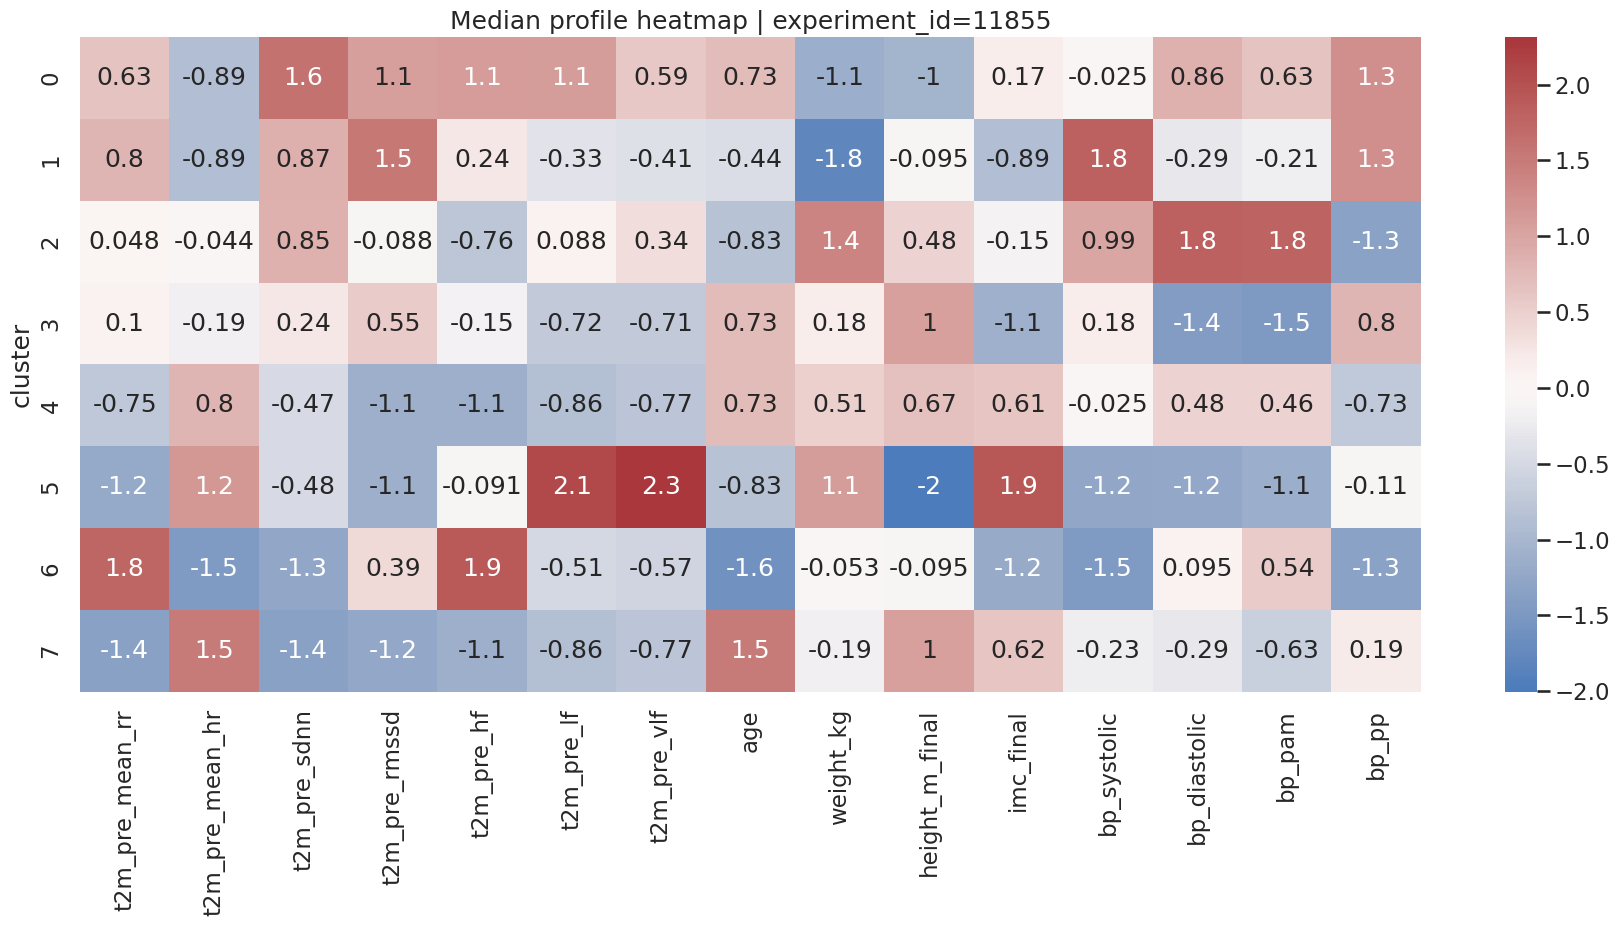

In [20]:
# ============================================
# 13. Z-scored median profile heatmap
# ============================================

def plot_cluster_profile_heatmap(df: pd.DataFrame, variables: list, title: str = ""):
    prof = df.groupby("cluster")[variables].median()

    prof_z = prof.apply(
        lambda col: (col - col.mean()) / col.std(ddof=0) if col.std(ddof=0) > 0 else 0.0,
        axis=0
    )

    plt.figure(figsize=(max(16, len(variables) * 1.2), max(6, prof.shape[0] * 1.2)))
    sns.heatmap(prof_z, annot=True, cmap="vlag", center=0)
    plt.title(title if title else "Cluster median profile heatmap")
    plt.tight_layout()
    plt.show()

plot_cluster_profile_heatmap(
    test_df,
    HRV_VARS + CONT_VARS,
    title=f"Median profile heatmap | experiment_id={test_exp_id}"
)

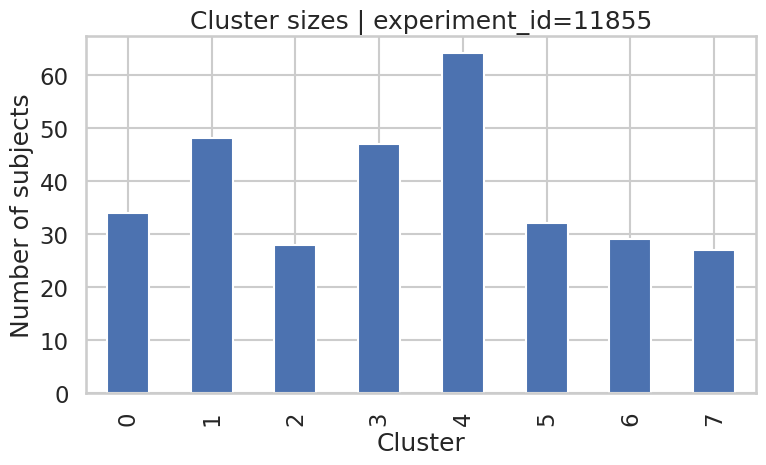

In [21]:
# ============================================
# 14. Cluster size visualization
# ============================================

def plot_cluster_sizes(df: pd.DataFrame, title: str = ""):
    counts = df["cluster"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title(title if title else "Cluster sizes")
    plt.xlabel("Cluster")
    plt.ylabel("Number of subjects")
    plt.tight_layout()
    plt.show()

plot_cluster_sizes(test_df, title=f"Cluster sizes | experiment_id={test_exp_id}")

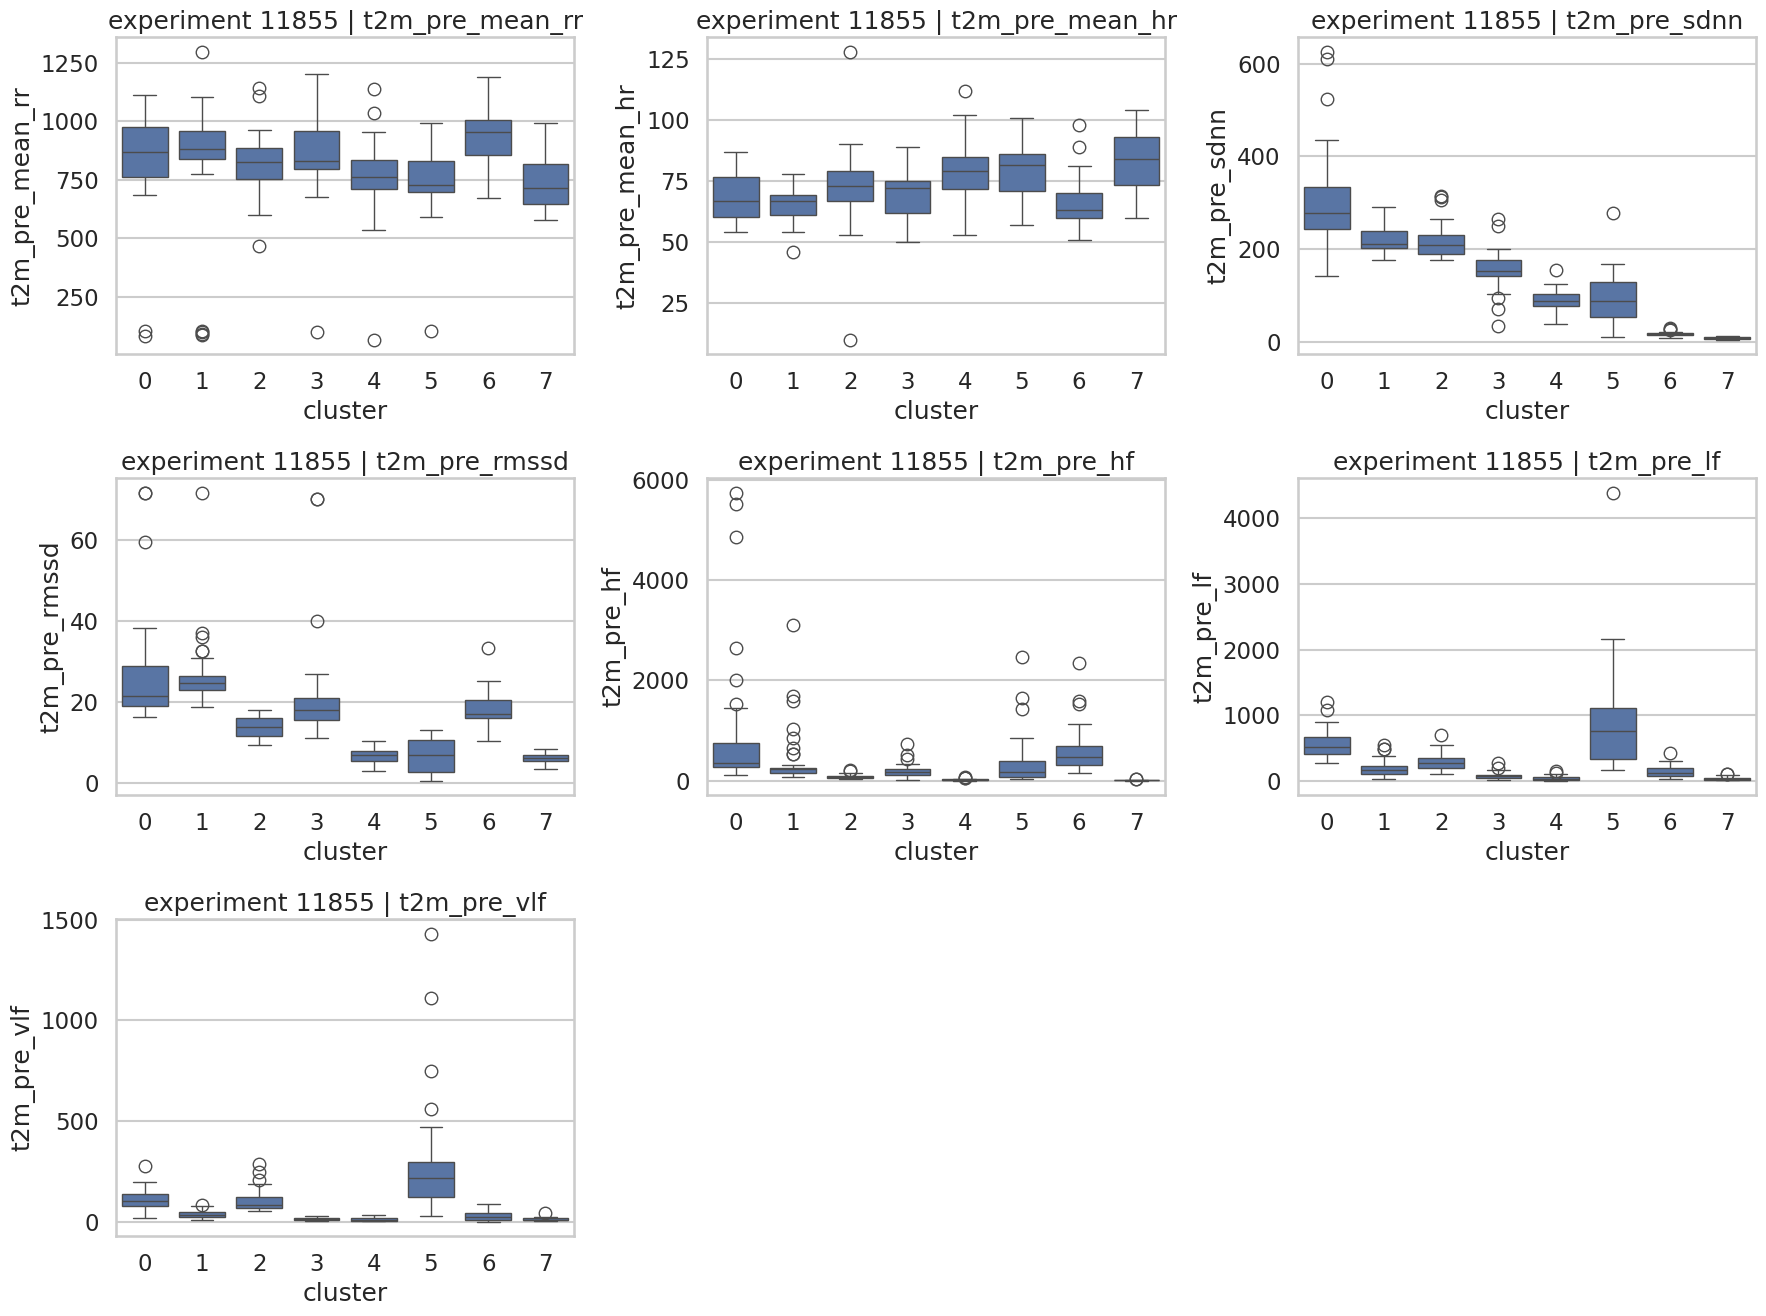

In [22]:
# ============================================
# 15. Boxplots for selected continuous variables
# ============================================

def plot_boxplots_by_cluster(df: pd.DataFrame, variables: list, ncols: int = 3, title_prefix: str = ""):
    vars_present = [v for v in variables if v in df.columns]
    n = len(vars_present)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4.5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, var in zip(axes, vars_present):
        sns.boxplot(data=df, x="cluster", y=var, ax=ax)
        ax.set_title(f"{title_prefix}{var}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_boxplots_by_cluster(
    test_df,
    HRV_VARS,
    ncols=3,
    title_prefix=f"experiment {test_exp_id} | "
)

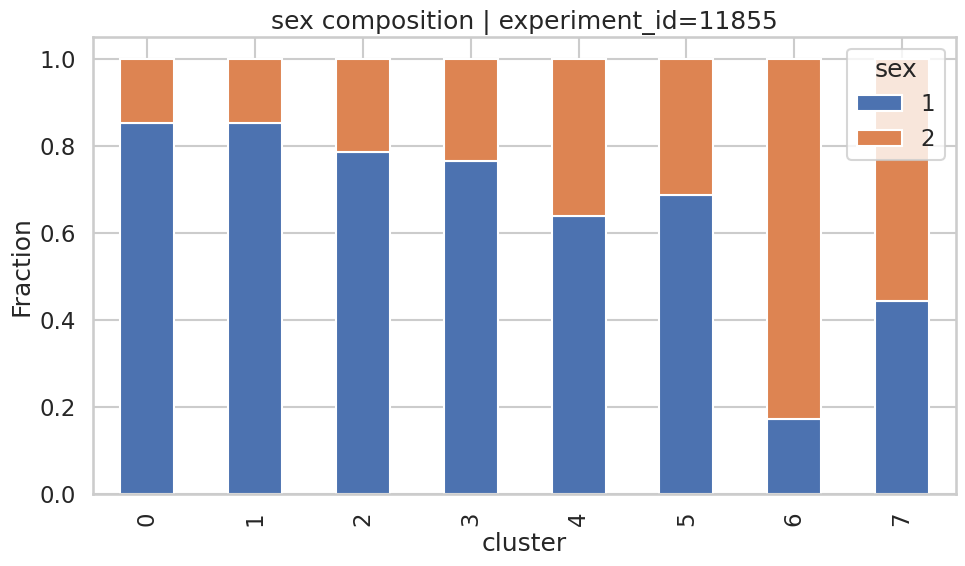

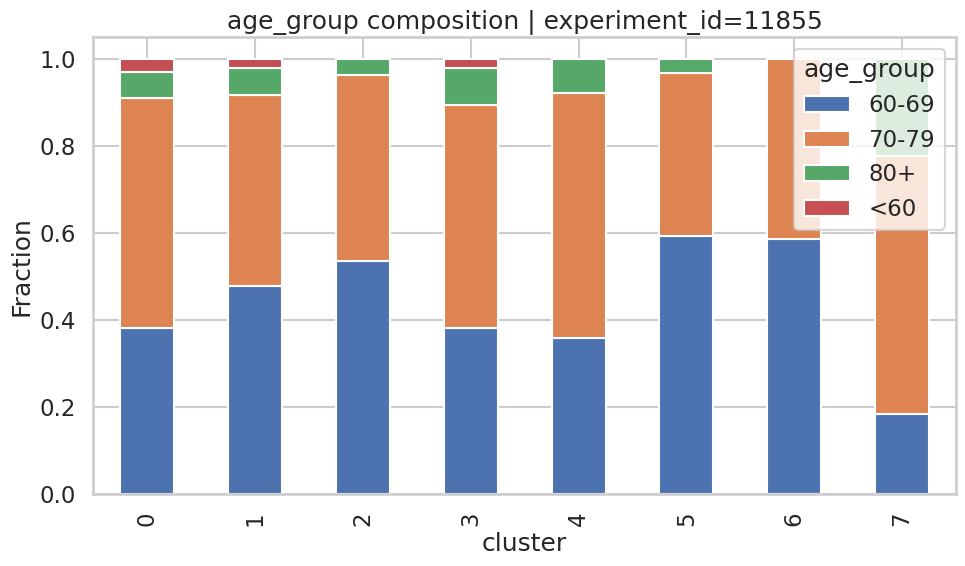

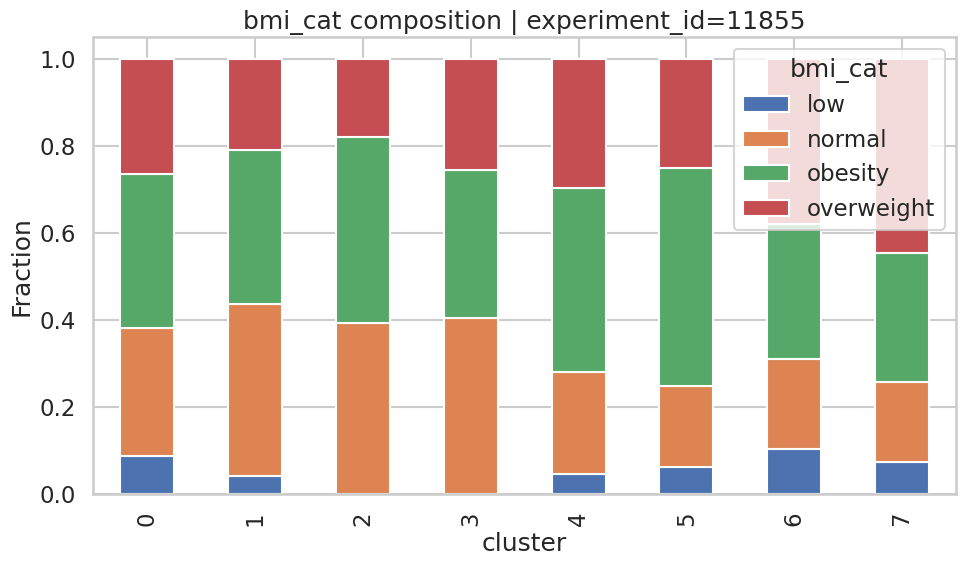

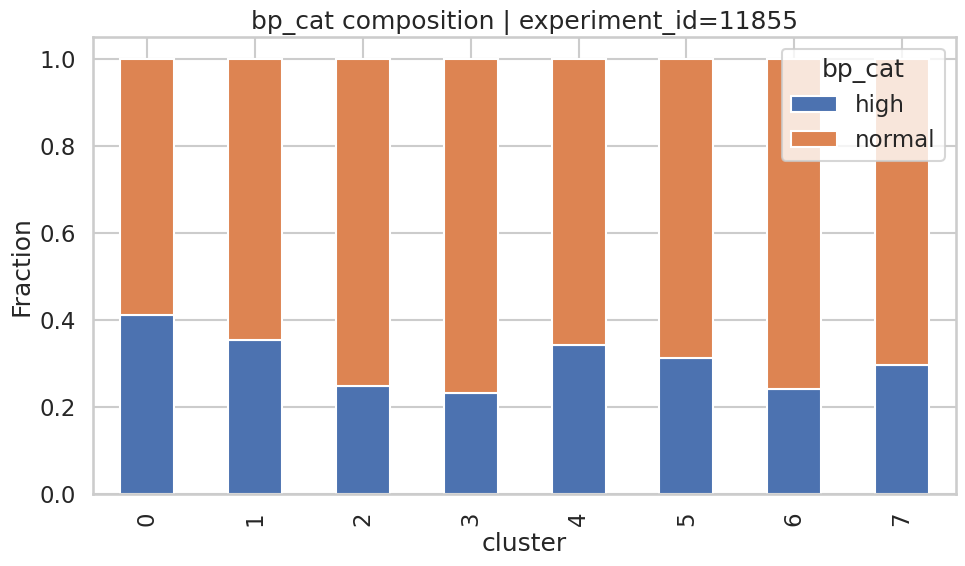

In [23]:
# ============================================
# 16. Categorical composition plots
# ============================================

def plot_categorical_composition(df: pd.DataFrame, var: str, title: str = ""):
    tmp = (
        df.groupby(["cluster", var])
        .size()
        .reset_index(name="n")
    )

    totals = df.groupby("cluster").size().rename("cluster_total").reset_index()
    tmp = tmp.merge(totals, on="cluster", how="left")
    tmp["fraction"] = tmp["n"] / tmp["cluster_total"]

    pivot = tmp.pivot(index="cluster", columns=var, values="fraction").fillna(0)

    pivot.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title(title if title else f"Categorical composition | {var}")
    plt.ylabel("Fraction")
    plt.tight_layout()
    plt.show()

for cat_var in CAT_VARS:
    if cat_var in test_df.columns:
        plot_categorical_composition(
            test_df,
            cat_var,
            title=f"{cat_var} composition | experiment_id={test_exp_id}"
        )

In [25]:
# ============================================
# 17. HRV-only relative profile
# ============================================

def median_absolute_deviation(x: pd.Series) -> float:
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    med = x.median()
    return float(np.median(np.abs(x - med)))


def get_hrv_relative_profile(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    prof = df.groupby("cluster")[variables].median()

    def robust_scale(col: pd.Series) -> pd.Series:
        med = col.median()
        mad = median_absolute_deviation(col)
        if pd.isna(mad) or mad == 0:
            return pd.Series(np.zeros(len(col)), index=col.index, dtype=float)
        return (col - med) / mad

    rel = prof.apply(robust_scale, axis=0)
    return rel

hrv_relative_test = get_hrv_relative_profile(test_df, HRV_VARS)
hrv_relative_test

,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf
cluster,,,,,,,
0,0.717300,-0.916667,1.773371,0.843537,1.491054,3.436916,3.805195
1,0.936709,-0.916667,1.008499,1.265306,0.445328,0.198598,0.272727
2,-0.033755,0.083333,0.991501,-0.217687,-0.779324,1.161215,2.948052
3,0.033755,-0.083333,0.368272,0.367347,-0.035785,-0.675234,-0.792208
4,-1.063291,1.083333,-0.368272,-1.156463,-1.220676,-1.007009,-1.000000
5,-1.679325,1.500000,-0.379603,-1.156463,0.035785,5.759346,9.909091
6,2.177215,-1.583333,-1.171671,0.217687,2.461233,-0.198598,-0.272727
7,-1.856540,1.916667,-1.278187,-1.265306,-1.220676,-0.992991,-1.000000


In [26]:
# ============================================
# 18. Full characterization function for one partition
# ============================================

def characterize_partition(experiment_id: int) -> dict:
    df = attach_partition_to_data(experiment_id, drop_noise=True)

    cluster_sizes = (
        df["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n")
    )
    cluster_sizes["fraction"] = cluster_sizes["n"] / cluster_sizes["n"].sum()

    cont_summary = summarize_continuous_by_cluster(df, HRV_VARS + CONT_VARS)
    cat_summary = summarize_categorical_by_cluster(df, CAT_VARS)

    cont_comparison = compare_continuous_across_clusters(df, HRV_VARS + CONT_VARS)
    cat_comparison = compare_categorical_across_clusters(df, CAT_VARS)

    median_profiles = cluster_median_profile(df, HRV_VARS + CONT_VARS).reset_index()

    return {
        "experiment_id": experiment_id,
        "data": df,
        "cluster_sizes": cluster_sizes,
        "cont_summary": cont_summary,
        "cat_summary": cat_summary,
        "cont_comparison": cont_comparison,
        "cat_comparison": cat_comparison,
        "median_profiles": median_profiles,
    }

In [27]:
# ============================================
# 19. Run characterization for all selected partitions
# ============================================

characterization_results = {}
failed = []

for exp_id in SELECTED_EXPERIMENT_IDS:
    try:
        characterization_results[int(exp_id)] = characterize_partition(int(exp_id))
    except Exception as e:
        failed.append((exp_id, str(e)))

print("characterized", len(characterization_results))
print("failed", len(failed))

if failed:
    display(pd.DataFrame(failed, columns=["experiment_id", "error"]))

characterized 10
failed 0


In [28]:
# ============================================
# 20. Build ranking table of "interestingness"
# ============================================

def summarize_partition_strength(exp_id: int, res: dict) -> dict:
    cont_cmp = res["cont_comparison"].copy()
    cat_cmp = res["cat_comparison"].copy()

    n_sig_cont = int((cont_cmp["p_adj_fdr"] < 0.05).sum()) if not cont_cmp.empty else 0
    n_sig_cat = int((cat_cmp["p_adj_fdr"] < 0.05).sum()) if not cat_cmp.empty else 0

    mean_eff_cont = float(cont_cmp["effect_size"].mean()) if not cont_cmp.empty else np.nan
    mean_eff_cat = float(cat_cmp["effect_size"].mean()) if not cat_cmp.empty else np.nan

    hrv_cmp = cont_cmp.loc[cont_cmp["variable"].isin(HRV_VARS)].copy()
    ext_cmp = pd.concat([
        cont_cmp.loc[cont_cmp["variable"].isin(CONT_VARS)],
        cat_cmp.loc[cat_cmp["variable"].isin(CAT_VARS)]
    ], ignore_index=True)

    mean_eff_hrv = float(hrv_cmp["effect_size"].mean()) if not hrv_cmp.empty else np.nan
    mean_eff_ext = float(ext_cmp["effect_size"].mean()) if not ext_cmp.empty else np.nan

    return {
        "experiment_id": exp_id,
        "n_clusters_real": res["data"]["cluster"].nunique(),
        "min_cluster_size_real": int(res["cluster_sizes"]["n"].min()),
        "max_cluster_size_real": int(res["cluster_sizes"]["n"].max()),
        "n_sig_cont": n_sig_cont,
        "n_sig_cat": n_sig_cat,
        "mean_eff_cont": mean_eff_cont,
        "mean_eff_cat": mean_eff_cat,
        "mean_eff_hrv": mean_eff_hrv,
        "mean_eff_ext": mean_eff_ext,
    }

strength_rows = [
    summarize_partition_strength(exp_id, res)
    for exp_id, res in characterization_results.items()
]

strength_df = pd.DataFrame(strength_rows)
strength_df = selected_meta_df.merge(strength_df, on="experiment_id", how="left")
strength_df.sort_values(["mean_eff_hrv", "mean_eff_ext", "S_primary"], ascending=False)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,pass_k,pass_min_cluster,pass_noise,pass_silhouette,pass_max_cluster_fraction,pass_all_filters,k_penalty,sil_norm,db_norm,ch_norm,noise_norm,S_struct,hrv_var_reduction,hrv_iqr_compactness,S_hrv_intra_raw,S_hrv_rel_raw,E_ext_raw,D_dom_raw,S_desc_raw,hrv_intra_norm,hrv_rel_norm,desc_norm,struct_norm,S_primary,n_clusters_real,min_cluster_size_real,max_cluster_size_real,n_sig_cont,n_sig_cat,mean_eff_cont,mean_eff_cat,mean_eff_hrv,mean_eff_ext
0,ok,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.05, ""min_samples"": 20, ...",8,221,0.416981,309,27.0,64.0,33.0,2.931699,2.370370,0.753995,8215.086578,0.323285,11855,True,True,True,True,True,True,0,0.901504,0.984895,0.850820,0.166038,0.782002,0.387362,0.391884,0.389171,0.725227,0.052143,0.633390,-0.153517,0.870502,0.386885,0.203825,1.000000,0.672818,8,27,64,7,1,0.296492,0.137427,0.624480,0.052143
1,ok,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.05, ""min_samples"": 5, ""...",8,216,0.407547,314,26.0,55.0,37.5,2.950280,2.115385,0.731911,7460.501413,0.374507,11822,True,True,True,True,True,True,0,0.875060,0.973763,0.772445,0.184906,0.750756,0.387135,0.332986,0.365475,0.701395,0.051639,0.646874,-0.157915,0.824216,0.333707,0.196768,0.959842,0.634531,8,26,55,7,1,0.291142,0.137323,0.613823,0.051639
2,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 6}",6,0,0.000000,530,10.0,172.0,84.5,1.991712,17.200000,0.277803,152.634911,1.167301,4,True,True,True,True,True,True,0,0.331289,0.801458,0.013420,1.000000,0.359744,0.585317,0.109559,0.395014,0.919407,0.030395,0.578044,-0.152137,0.881916,0.820168,0.206038,0.457288,0.628234,6,10,172,8,1,0.213354,0.080702,0.451197,0.030395
3,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 5}",5,0,0.000000,530,15.0,172.0,157.0,1.889536,11.466667,0.257802,153.493475,1.274984,3,True,True,True,True,True,True,0,0.307339,0.778054,0.013509,1.000000,0.344362,0.532267,0.101938,0.360135,0.907367,0.028263,0.667085,-0.180342,0.813785,0.793304,0.160790,0.437519,0.585023,5,15,172,8,1,0.206924,0.074317,0.437424,0.028263
9,ok,affinity_propagation,message-passing,umap_integrated_nn10_md01,"{""damping"": 0.7, ""preference"": -50}",9,0,0.000000,530,52.0,73.0,57.0,3.160902,1.403846,0.426290,687.779842,0.772069,14469,True,True,True,True,True,True,1,0.509094,0.887357,0.069003,1.000000,0.361641,0.262609,-0.157310,0.094641,0.897754,0.309491,0.156056,0.169827,0.295170,0.771852,0.722562,0.459727,0.517124,9,52,73,15,4,0.304581,0.352360,0.323467,0.309491
5,ok,birch,hierarchical-centroid,umap_integrated_nn10_md00,"{""branching_factor"": 25, ""n_clusters"": 7, ""thr...",7,0,0.000000,530,54.0,105.0,76.0,2.761949,1.944444,0.428874,682.020629,0.769182,13944,True,True,True,True,True,True,0,0.512189,0.887985,0.068404,1.000000,0.462763,0.249133,-0.146202,0.090999,0.936298,0.240881,0.169598,0.117737,0.288055,0.857859,0.638995,0.589694,0.547614,7,54,105,15,4,0.254369,0.316323,0.312894,0.240881
4,ok,gmm,model-based,umap_integrated_nn10_md00,"{""covariance_type"": ""tied"", ""n_components"": 7}",7,0,0.000000,530,50.0,103.0,75.0,2.761043,2.060000,0.424741,670.850498,0.776710,13436,True,True,True,True,True,True,0,0.507240,0.886349,0.067244,1.000000,0.460250,0.226298,-0.133862,0.082234,0.962624,0.244819,0.162468,0.122633,0.270933,0.916600,0.646849,0.586465,0.554132,7,50,103,15,4,0.246968,0.324693,0.295067,0.244819
7,ok,leiden_knn,community-graph,umap_integrated_nn10_md03,"{""n_neighbors"": 20, ""resolution"": 0.5}",6,0,0.000000,530,42.0,133.0,88.5,2.494307,3.166667,0.373335,463.754029,0.791349,15252,True,True,True,True,True,True,0,0.445684,0.883167,0.045734,1.000000,0.432373,0.250624,-0.174747,0.080476,0.946541,0.252893,0.185960,0.121237,0.267499,0.880714,0.644610,0.550636,0.536348,6,42,133,15,4,0.250516,0.327

In [29]:
# ============================================
# 21. Inspect one partition deeply
# ============================================

INSPECT_EXPERIMENT_ID = int(strength_df.sort_values("mean_eff_hrv", ascending=False).iloc[0]["experiment_id"])
inspect_res = characterization_results[INSPECT_EXPERIMENT_ID]

print("Inspecting experiment_id", INSPECT_EXPERIMENT_ID)

display(inspect_res["cluster_sizes"])
display(inspect_res["cont_comparison"].sort_values("effect_size", ascending=False))
display(inspect_res["cat_comparison"].sort_values("effect_size", ascending=False))
display(inspect_res["median_profiles"])

Inspecting experiment_id 11855


,cluster,n,fraction
0,0,34,0.110032
1,1,48,0.155340
2,2,28,0.090615
3,3,47,0.152104
4,4,64,0.207120
5,5,32,0.103560
6,6,29,0.093851
7,7,27,0.087379


,variable,type,test,statistic,p_value,effect_size,p_adj_fdr
2,t2m_pre_sdnn,continuous,kruskal,264.651026,2.101419e-53,0.873393,3.152129e-52
3,t2m_pre_rmssd,continuous,kruskal,250.829059,1.845565e-50,0.818218,1.384173e-49
5,t2m_pre_lf,continuous,kruskal,233.780101,7.806771e-47,0.753422,3.903386e-46
4,t2m_pre_hf,continuous,kruskal,229.943266,5.102912e-46,0.740675,1.913592e-45
6,t2m_pre_vlf,continuous,kruskal,219.878722,7.000781e-44,0.707238,2.100234e-43
1,t2m_pre_mean_hr,continuous,kruskal,85.876124,8.673360e-16,0.262920,2.168340e-15
0,t2m_pre_mean_rr,continuous,kruskal,71.863636,6.202078e-13,0.215494,1.329017e-12
12,bp_diastolic,continuous,kruskal,15.096307,3.478451e-02,0.026898,6.522096e-02
7,age,continuous,kruskal,13.117596,6.929450e-02,0.020324,1.154908e-01
14,bp_pp,continuous,kruskal,12.795013,7.726318e-02,0.019253,1.158948e-01


,variable,type,test,statistic,p_value,effect_size,p_adj_fdr
0,sex,categorical,chi2,55.400578,1.241811e-09,0.396324,4.967243e-09
1,age_group,categorical,chi2,29.259917,1.078999e-01,0.094466,2.157998e-01
2,bmi_cat,categorical,chi2,24.254691,2.808824e-01,0.058917,3.745098e-01
3,bp_cat,categorical,chi2,4.820231,6.818904e-01,0.000000,6.818904e-01


,cluster,t2m_pre_mean_rr,t2m_pre_mean_hr,t2m_pre_sdnn,t2m_pre_rmssd,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,age,weight_kg,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp
0,0,868.5,67.0,278.0,21.5,357.0,514.0,102.5,71.0,70.0,1.525,30.163014,128.5,79.0,95.166667,55.5
1,1,881.5,67.0,210.5,24.6,225.5,167.5,34.5,69.5,68.0,1.550,29.173207,133.0,76.0,93.500000,55.5
2,2,824.0,73.0,209.0,13.7,71.5,270.5,86.0,69.0,77.7,1.565,29.867827,131.0,81.5,97.500000,47.0
3,3,828.0,72.0,154.0,18.0,165.0,74.0,14.0,71.0,74.0,1.580,28.972648,129.0,73.0,91.000000,54.0
4,4,763.0,79.0,89.0,6.8,16.0,38.5,10.0,71.0,75.0,1.570,30.582200,128.5,78.0,94.833333,49.0
5,5,726.5,81.5,88.0,6.8,174.0,762.5,220.0,69.0,76.8,1.500,31.829382,125.5,73.5,91.666667,51.0
6,6,955.0,63.0,18.1,16.9,479.0,125.0,24.0,68.0,73.3,1.550,28.880487,125.0,77.0,95.000000,47.0
7,7,716.0,84.0,8.7,6.0,16.0,40.0,10.0,72.0,72.9,1.580,30.588020,128.0,76.0,92.666667,52.0


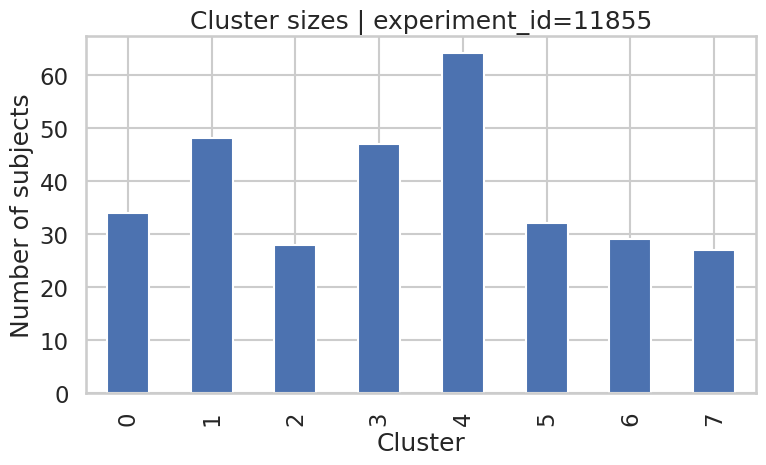

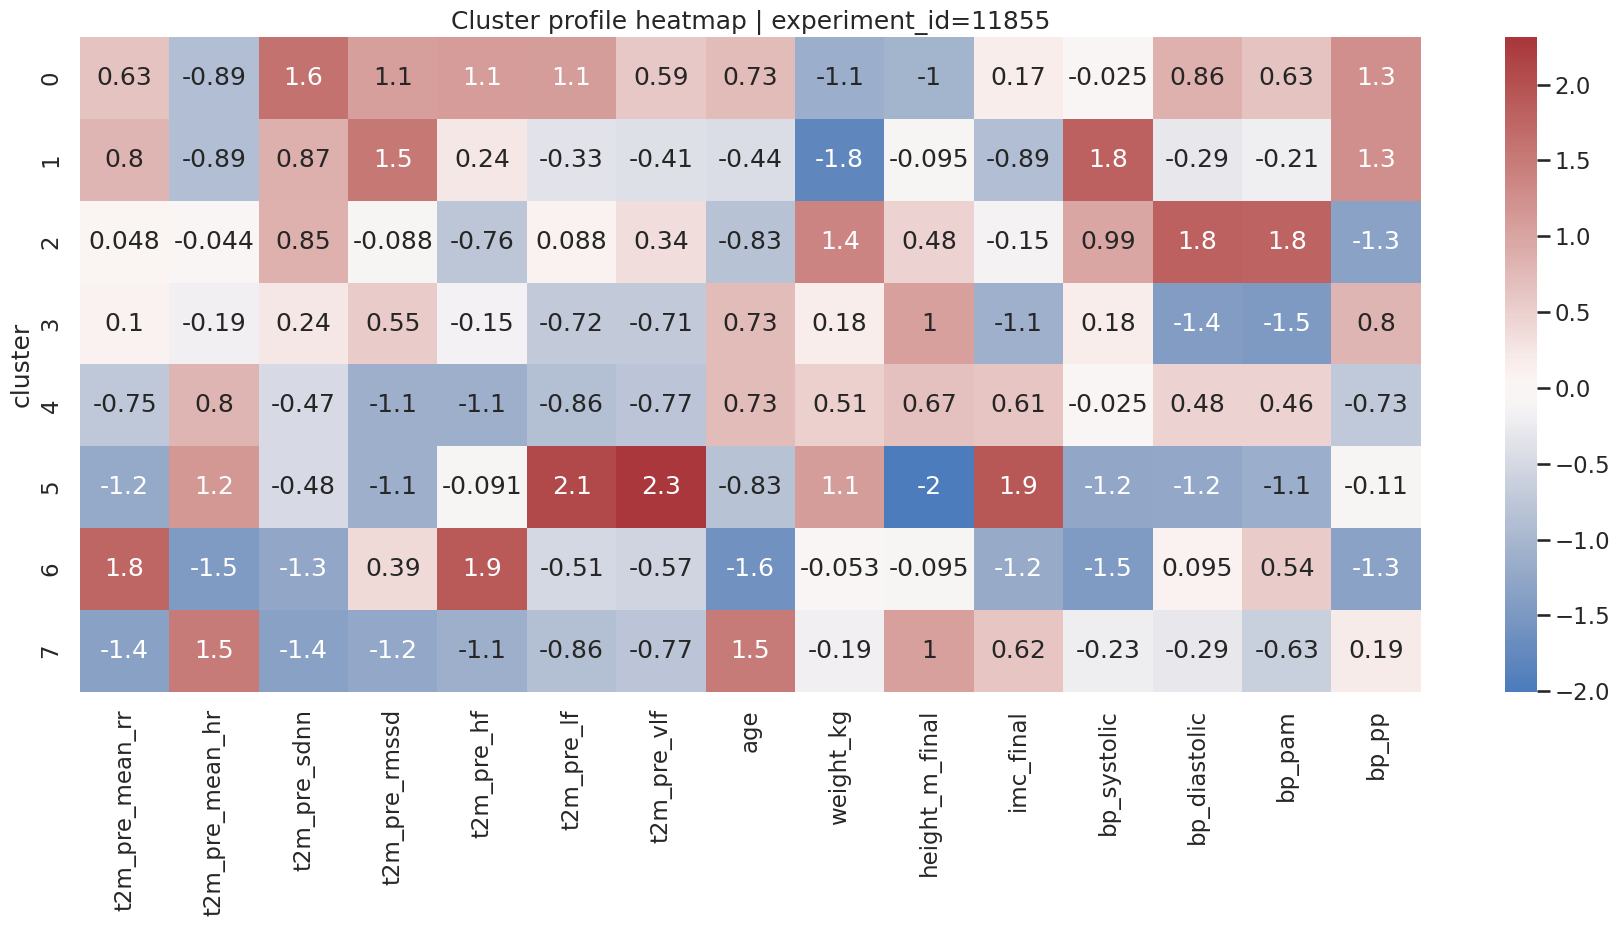

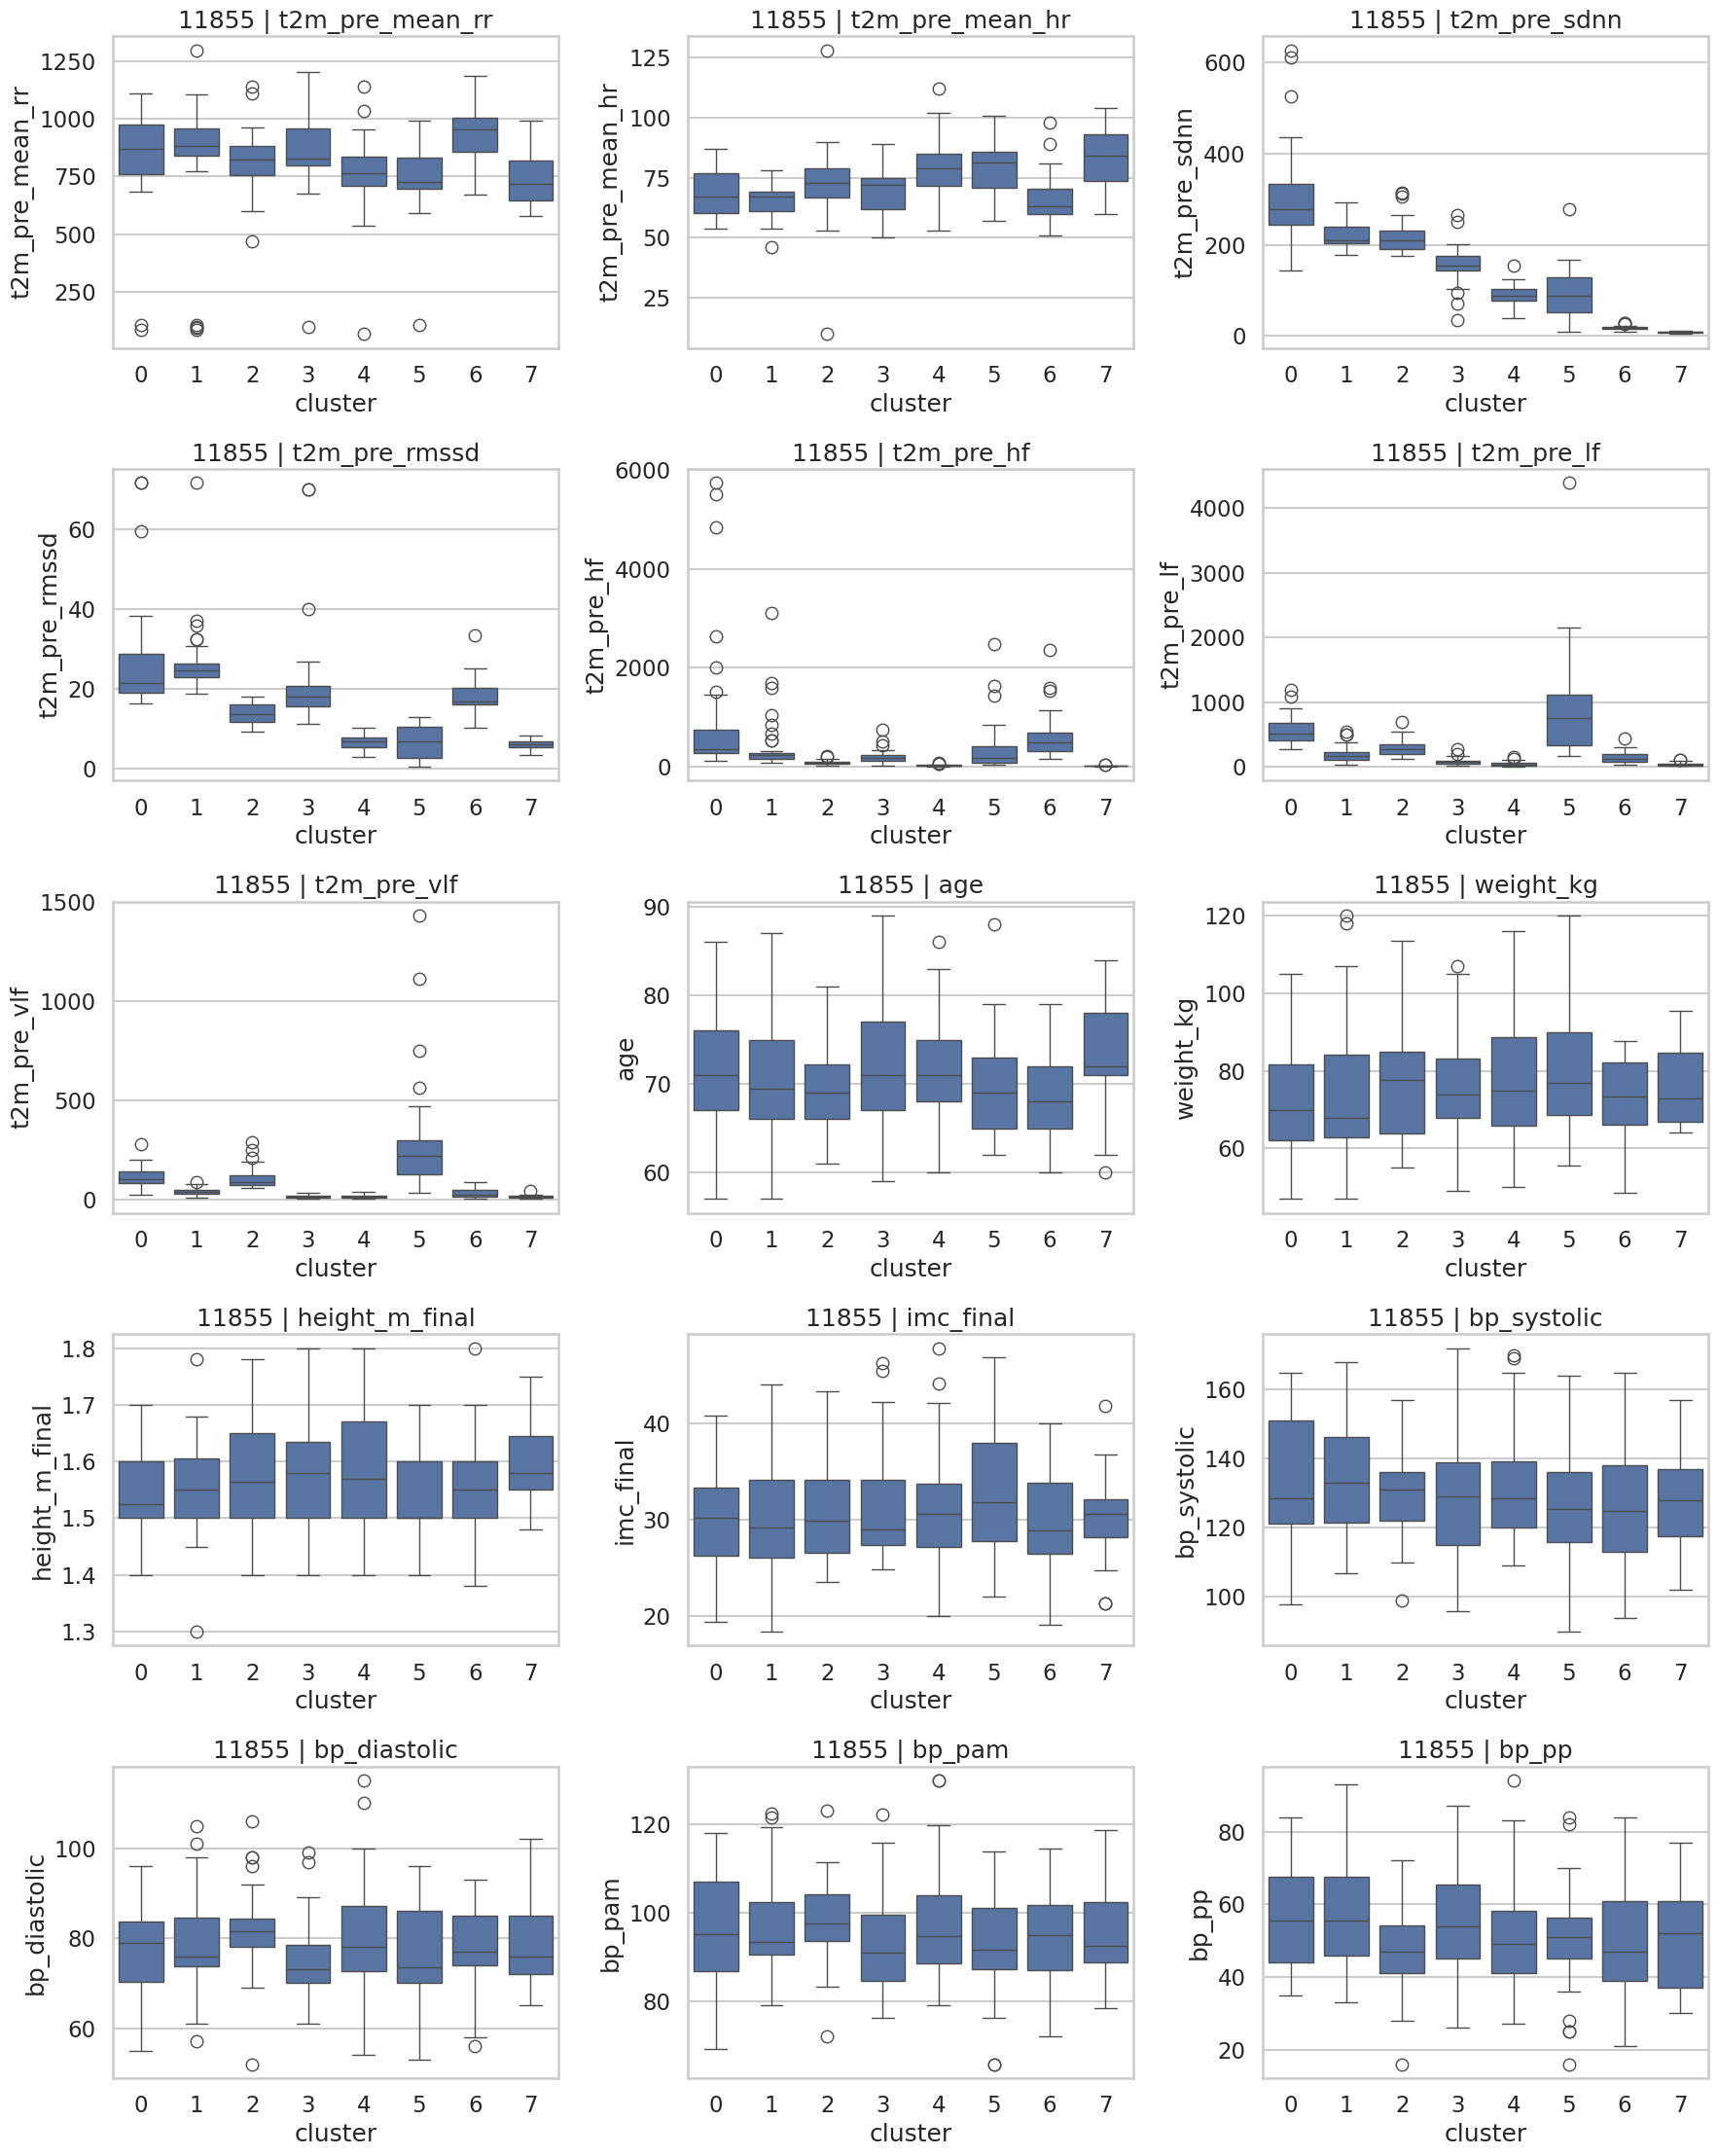

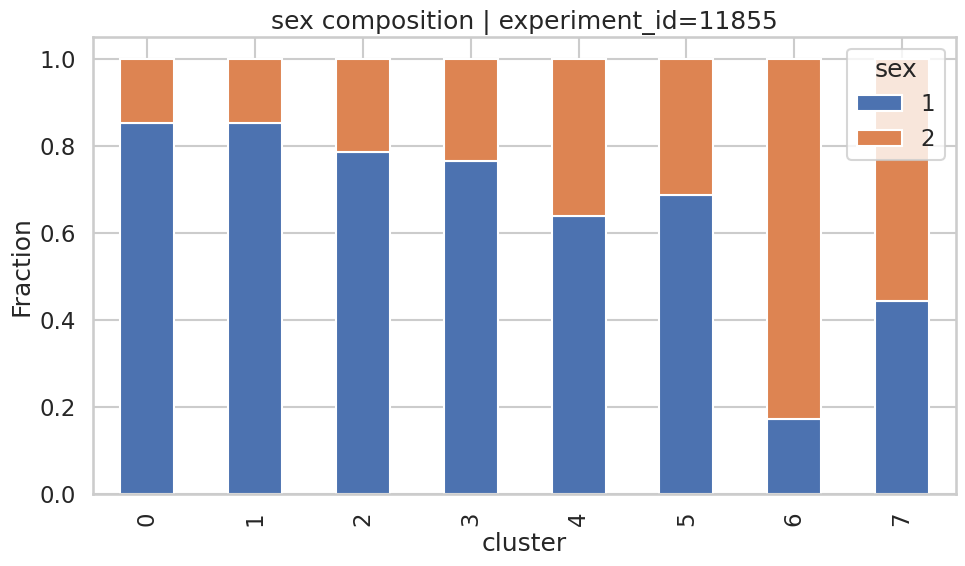

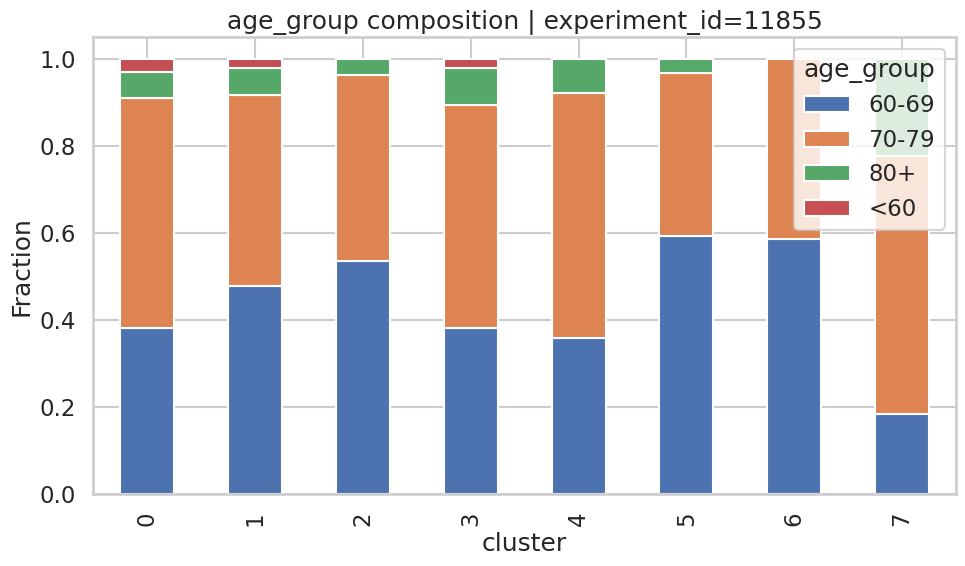

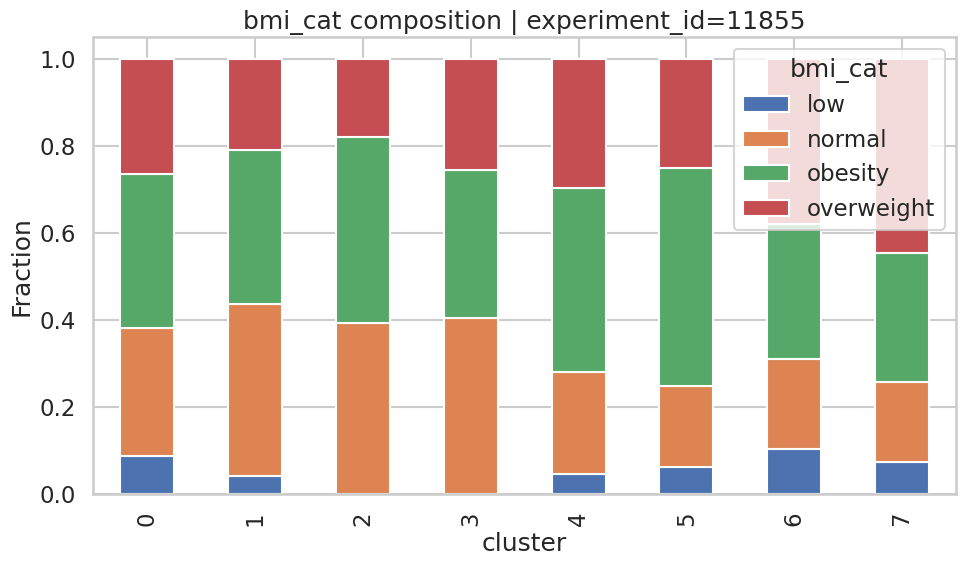

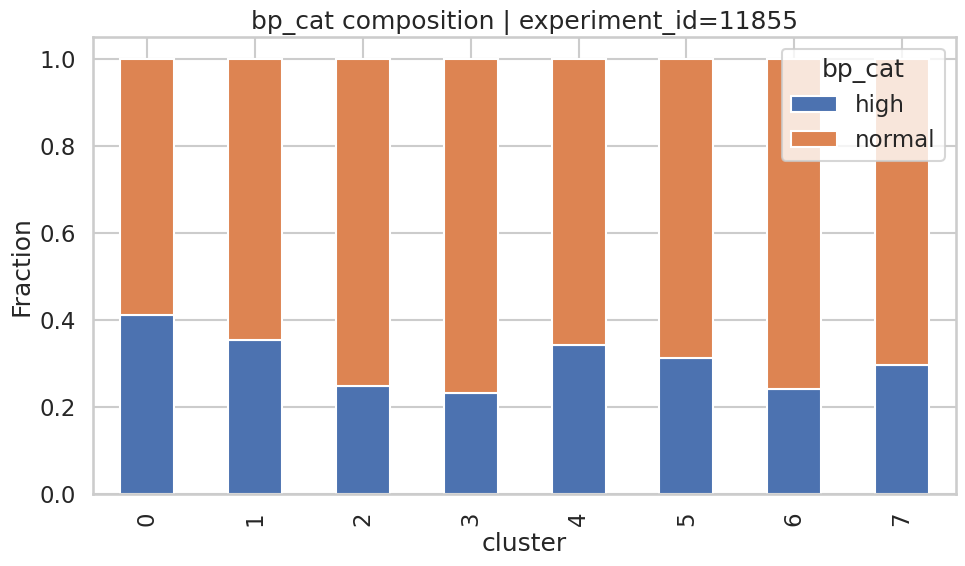

In [30]:
# ============================================
# 22. Visual package for one partition
# ============================================

inspect_df = inspect_res["data"]

plot_cluster_sizes(inspect_df, title=f"Cluster sizes | experiment_id={INSPECT_EXPERIMENT_ID}")

plot_cluster_profile_heatmap(
    inspect_df,
    HRV_VARS + CONT_VARS,
    title=f"Cluster profile heatmap | experiment_id={INSPECT_EXPERIMENT_ID}"
)

plot_boxplots_by_cluster(
    inspect_df,
    HRV_VARS + CONT_VARS,
    ncols=3,
    title_prefix=f"{INSPECT_EXPERIMENT_ID} | "
)

for cat_var in CAT_VARS:
    if cat_var in inspect_df.columns:
        plot_categorical_composition(
            inspect_df,
            cat_var,
            title=f"{cat_var} composition | experiment_id={INSPECT_EXPERIMENT_ID}"
        )

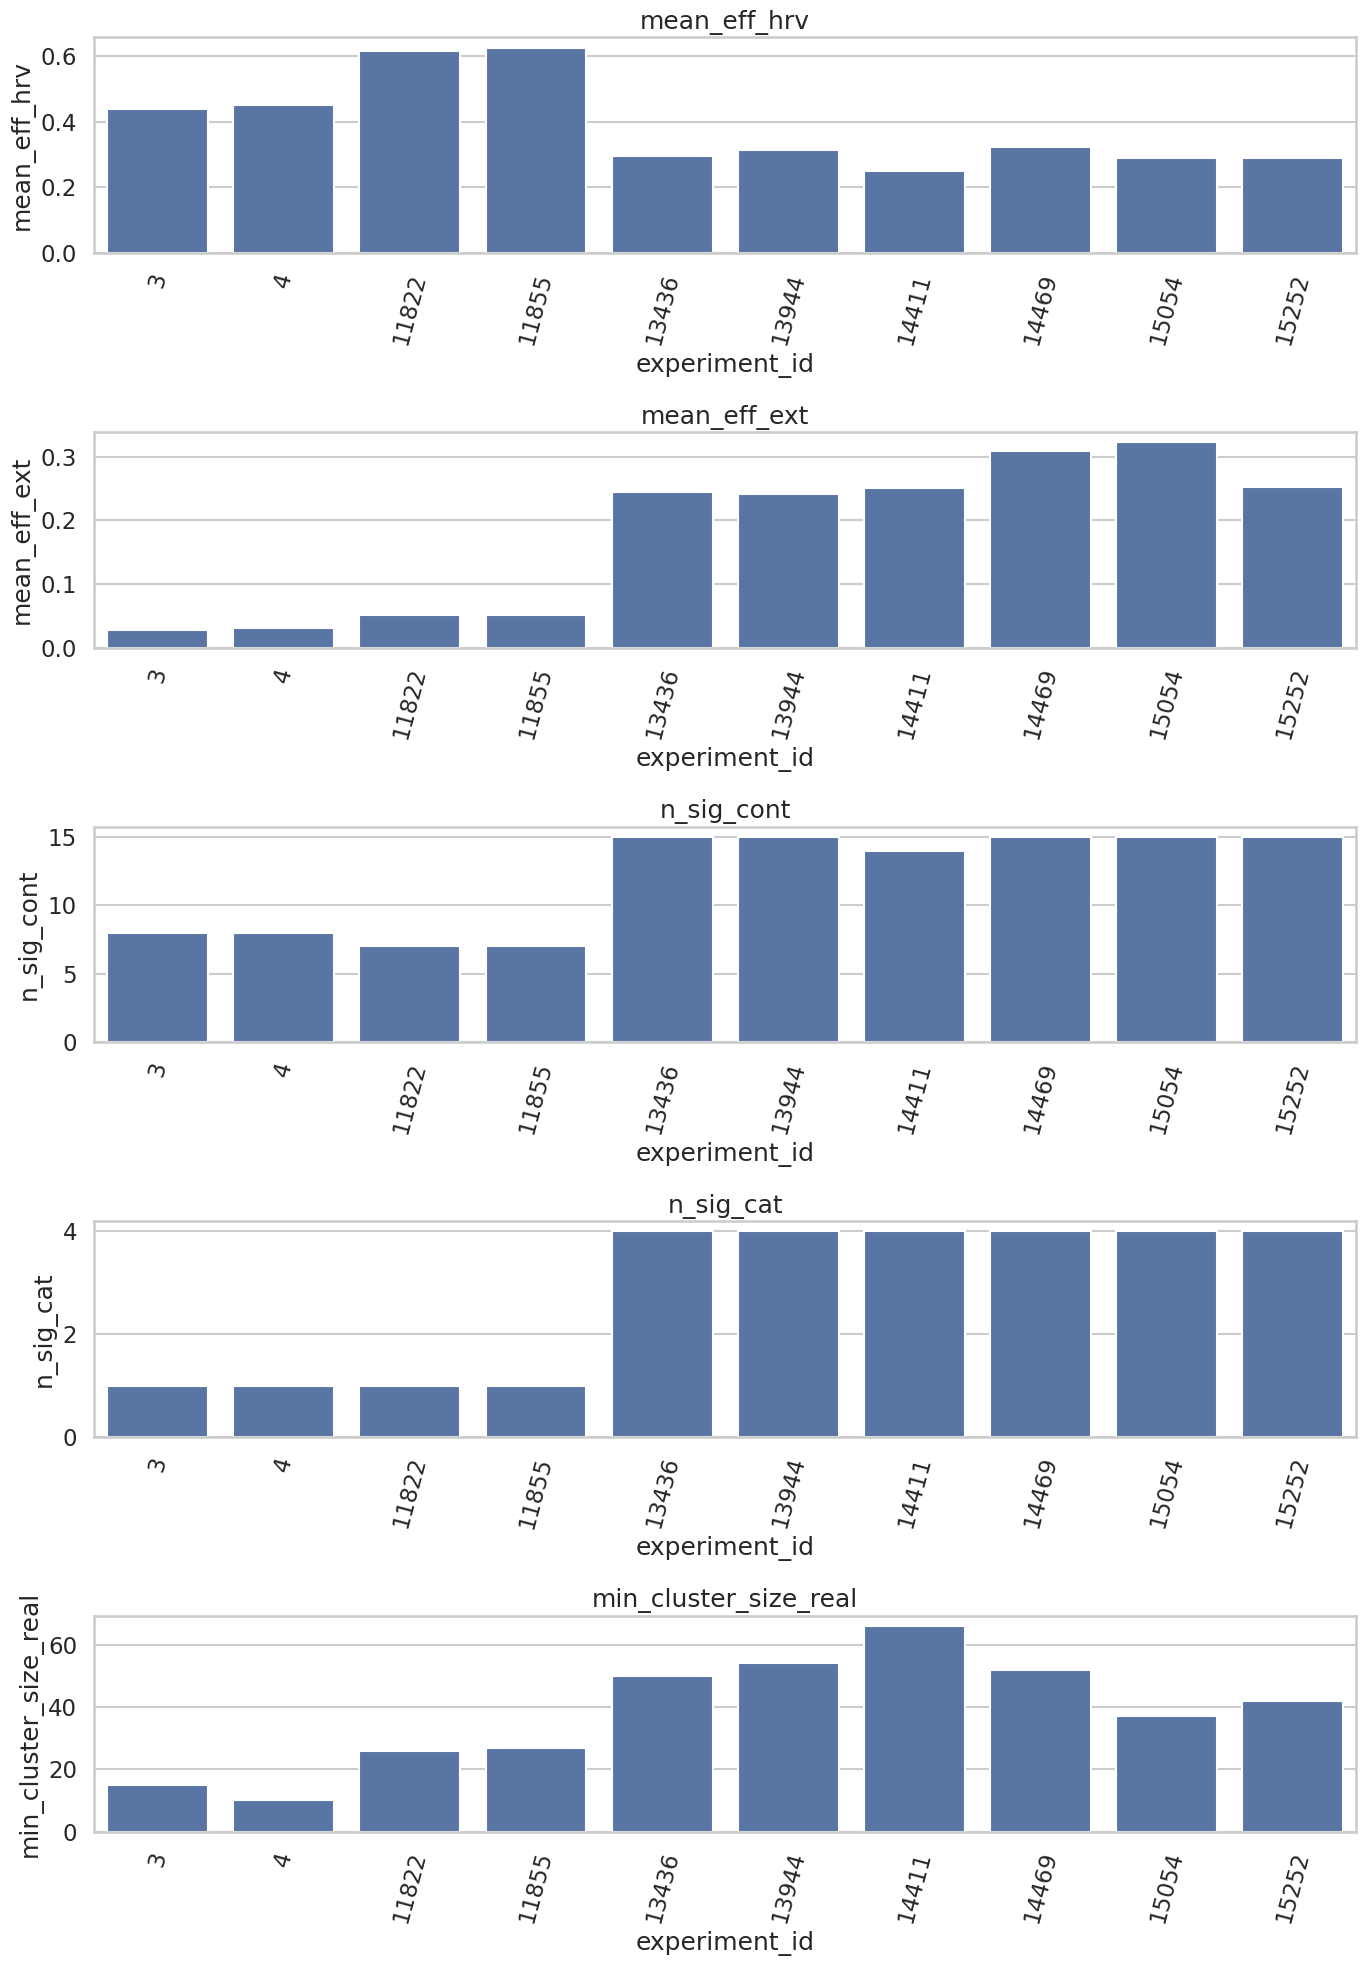

In [31]:
# ============================================
# 23. Compare all selected partitions visually
# ============================================

plot_df = strength_df.copy()

metrics_to_plot = [
    "mean_eff_hrv",
    "mean_eff_ext",
    "n_sig_cont",
    "n_sig_cat",
    "min_cluster_size_real",
]

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(14, 4 * len(metrics_to_plot)))

for ax, metric in zip(axes, metrics_to_plot):
    tmp = plot_df.sort_values(metric, ascending=False)
    sns.barplot(data=tmp, x="experiment_id", y=metric, ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# 24. Export all characterization outputs
# ============================================

for exp_id, res in characterization_results.items():
    exp_dir = OUT_DIR / f"experiment_{exp_id}"
    exp_dir.mkdir(parents=True, exist_ok=True)

    res["cluster_sizes"].to_csv(exp_dir / "cluster_sizes.csv", index=False)
    res["cont_summary"].to_csv(exp_dir / "continuous_summary_by_cluster.csv", index=False)
    res["cat_summary"].to_csv(exp_dir / "categorical_summary_by_cluster.csv", index=False)
    res["cont_comparison"].to_csv(exp_dir / "continuous_cluster_comparison.csv", index=False)
    res["cat_comparison"].to_csv(exp_dir / "categorical_cluster_comparison.csv", index=False)
    res["median_profiles"].to_csv(exp_dir / "median_profiles.csv", index=False)

strength_df.to_csv(OUT_DIR / "selected_partition_strength_summary.csv", index=False)

print("Saved characterization outputs to", OUT_DIR.resolve())

Saved characterization outputs to /home/dmedina/Desktop/colabs/HRV_analysis/results/cluster_characterization_outputs


In [33]:
# ============================================
# 25. Compact decision table for discussion
# ============================================

decision_table = strength_df[[
    "experiment_id",
    "algorithm",
    "family",
    "space_name",
    "n_clusters",
    "S_primary",
    "mean_eff_hrv",
    "mean_eff_ext",
    "n_sig_cont",
    "n_sig_cat",
    "min_cluster_size_real",
    "max_cluster_size_real",
]].sort_values(
    ["mean_eff_hrv", "mean_eff_ext", "S_primary"],
    ascending=False
).reset_index(drop=True)

decision_table

,experiment_id,algorithm,family,space_name,n_clusters,S_primary,mean_eff_hrv,mean_eff_ext,n_sig_cont,n_sig_cat,min_cluster_size_real,max_cluster_size_real
0,11855,optics,density-based,umap_hrv_log_nn30_md00,8,0.672818,0.624480,0.052143,7,1,27,64
1,11822,optics,density-based,umap_hrv_log_nn30_md00,8,0.634531,0.613823,0.051639,7,1,26,55
2,4,kmeans,centroid-based,hrv_raw_scaled,6,0.628234,0.451197,0.030395,8,1,10,172
3,3,kmeans,centroid-based,hrv_raw_scaled,5,0.585023,0.437424,0.028263,8,1,15,172
4,14469,affinity_propagation,message-passing,umap_integrated_nn10_md01,9,0.517124,0.323467,0.309491,15,4,52,73
5,13944,birch,hierarchical-centroid,umap_integrated_nn10_md00,7,0.547614,0.312894,0.240881,15,4,54,105
6,13436,gmm,model-based,umap_integrated_nn10_md00,7,0.554132,0.295067,0.244819,15,4,50,103
7,15252,leiden_knn,community-graph,umap_integrated_nn10_md03,6,0.536348,0.290541,0.252893,15,4,42,133
8,15054,spectral,graph-based,umap_integrated_nn10_md03,9,0.523110,0.289033,0.322838,15,4,37,101
9,14411,spectral,graph-based,umap_integrated_nn10_md01,5,0.540487,0.248875,0.251291,14,4,66,138


In [34]:
# ============================================
# A. Figure saving utilities
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def save_current_figure(path: Path, dpi: int = 300) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()


def sanitize_filename(text: str) -> str:
    keep = []
    for ch in str(text):
        if ch.isalnum() or ch in ["_", "-", "."]:
            keep.append(ch)
        else:
            keep.append("_")
    return "".join(keep)

In [35]:
# ============================================
# B. Plotting functions with export support
# ============================================

def plot_cluster_sizes(df: pd.DataFrame, title: str = "", save_path: Path | None = None, show: bool = False):
    counts = df["cluster"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title(title if title else "Cluster sizes")
    plt.xlabel("Cluster")
    plt.ylabel("Number of subjects")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


def plot_cluster_profile_heatmap(
    df: pd.DataFrame,
    variables: list,
    title: str = "",
    save_path: Path | None = None,
    show: bool = False
):
    prof = df.groupby("cluster")[variables].median()

    prof_z = prof.apply(
        lambda col: (col - col.mean()) / col.std(ddof=0) if col.std(ddof=0) > 0 else 0.0,
        axis=0
    )

    plt.figure(figsize=(max(10, len(variables) * 0.9), max(4, prof.shape[0] * 0.7)))
    sns.heatmap(prof_z, annot=True, cmap="vlag", center=0)
    plt.title(title if title else "Cluster median profile heatmap")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


def plot_boxplots_by_cluster(
    df: pd.DataFrame,
    variables: list,
    ncols: int = 3,
    title_prefix: str = "",
    save_path: Path | None = None,
    show: bool = False
):
    vars_present = [v for v in variables if v in df.columns]
    n = len(vars_present)

    if n == 0:
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4.5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, var in zip(axes, vars_present):
        sns.boxplot(data=df, x="cluster", y=var, ax=ax)
        ax.set_title(f"{title_prefix}{var}")

    for ax in axes[n:]:
        ax.axis("off")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


def plot_categorical_composition(
    df: pd.DataFrame,
    var: str,
    title: str = "",
    save_path: Path | None = None,
    show: bool = False
):
    tmp = (
        df.groupby(["cluster", var])
        .size()
        .reset_index(name="n")
    )

    totals = df.groupby("cluster").size().rename("cluster_total").reset_index()
    tmp = tmp.merge(totals, on="cluster", how="left")
    tmp["fraction"] = tmp["n"] / tmp["cluster_total"]

    pivot = tmp.pivot(index="cluster", columns=var, values="fraction").fillna(0)

    pivot.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title(title if title else f"Categorical composition | {var}")
    plt.ylabel("Fraction")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


def median_absolute_deviation(x: pd.Series) -> float:
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    med = x.median()
    return float(np.median(np.abs(x - med)))


def get_hrv_relative_profile(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    prof = df.groupby("cluster")[variables].median()

    def robust_scale(col: pd.Series) -> pd.Series:
        med = col.median()
        mad = median_absolute_deviation(col)
        if pd.isna(mad) or mad == 0:
            return pd.Series(np.zeros(len(col)), index=col.index, dtype=float)
        return (col - med) / mad

    return prof.apply(robust_scale, axis=0)


def plot_hrv_relative_heatmap(
    df: pd.DataFrame,
    variables: list,
    title: str = "",
    save_path: Path | None = None,
    show: bool = False
):
    rel = get_hrv_relative_profile(df, variables)

    plt.figure(figsize=(max(8, len(variables) * 0.9), max(4, rel.shape[0] * 0.7)))
    sns.heatmap(rel, annot=True, cmap="vlag", center=0)
    plt.title(title if title else "HRV relative profile heatmap")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

In [36]:
# ============================================
# C. Text summary builders
# ============================================

def describe_top_continuous_differences(cont_comparison: pd.DataFrame, top_n: int = 8) -> str:
    if cont_comparison.empty:
        return "No continuous comparisons were available."

    tmp = cont_comparison.sort_values(
        ["effect_size", "p_adj_fdr"],
        ascending=[False, True]
    ).copy()

    lines = []
    for _, row in tmp.head(top_n).iterrows():
        lines.append(
            f"{row['variable']} | effect_size={row['effect_size']:.3f} | "
            f"p_adj_fdr={row['p_adj_fdr']:.3e}"
        )
    return "\n".join(lines)


def describe_top_categorical_differences(cat_comparison: pd.DataFrame, top_n: int = 8) -> str:
    if cat_comparison.empty:
        return "No categorical comparisons were available."

    tmp = cat_comparison.sort_values(
        ["effect_size", "p_adj_fdr"],
        ascending=[False, True]
    ).copy()

    lines = []
    for _, row in tmp.head(top_n).iterrows():
        lines.append(
            f"{row['variable']} | effect_size={row['effect_size']:.3f} | "
            f"p_adj_fdr={row['p_adj_fdr']:.3e}"
        )
    return "\n".join(lines)


def build_partition_summary_text(exp_meta: pd.Series, res: dict) -> str:
    cluster_sizes = res["cluster_sizes"].copy()
    cont_cmp = res["cont_comparison"].copy()
    cat_cmp = res["cat_comparison"].copy()

    lines = []
    lines.append(f"Experiment ID: {exp_meta['experiment_id']}")
    lines.append(f"Algorithm: {exp_meta['algorithm']}")
    lines.append(f"Family: {exp_meta['family']}")
    lines.append(f"Space: {exp_meta['space_name']}")
    lines.append(f"Requested k: {exp_meta['n_clusters']}")
    lines.append(f"Primary score: {exp_meta['S_primary']:.4f}" if "S_primary" in exp_meta else "Primary score: NA")
    lines.append("")
    lines.append("Cluster sizes")
    for _, row in cluster_sizes.iterrows():
        lines.append(
            f"Cluster {int(row['cluster'])}: n={int(row['n'])} | fraction={row['fraction']:.3f}"
        )

    lines.append("")
    lines.append("Top continuous differences")
    lines.append(describe_top_continuous_differences(cont_cmp))

    lines.append("")
    lines.append("Top categorical differences")
    lines.append(describe_top_categorical_differences(cat_cmp))

    return "\n".join(lines)

In [37]:
# ============================================
# D. Full export for one partition
# ============================================

def export_partition_report(
    experiment_id: int,
    exp_meta_df: pd.DataFrame,
    characterization_results: dict,
    out_dir: Path,
    hrv_vars: list,
    cont_vars: list,
    cat_vars: list,
    show_plots: bool = False
) -> None:
    exp_dir = out_dir / f"experiment_{experiment_id}"
    fig_dir = exp_dir / "figures"
    table_dir = exp_dir / "tables"
    text_dir = exp_dir / "text"

    fig_dir.mkdir(parents=True, exist_ok=True)
    table_dir.mkdir(parents=True, exist_ok=True)
    text_dir.mkdir(parents=True, exist_ok=True)

    res = characterization_results[experiment_id]
    exp_meta = exp_meta_df.loc[exp_meta_df["experiment_id"] == experiment_id].iloc[0]

    df = res["data"].copy()

    # Export tables
    res["cluster_sizes"].to_csv(table_dir / "cluster_sizes.csv", index=False)
    res["cont_summary"].to_csv(table_dir / "continuous_summary_by_cluster.csv", index=False)
    res["cat_summary"].to_csv(table_dir / "categorical_summary_by_cluster.csv", index=False)
    res["cont_comparison"].to_csv(table_dir / "continuous_cluster_comparison.csv", index=False)
    res["cat_comparison"].to_csv(table_dir / "categorical_cluster_comparison.csv", index=False)
    res["median_profiles"].to_csv(table_dir / "median_profiles.csv", index=False)

    hrv_relative = get_hrv_relative_profile(df, hrv_vars).reset_index()
    hrv_relative.to_csv(table_dir / "hrv_relative_profiles.csv", index=False)

    # Export metadata
    pd.DataFrame([exp_meta]).to_csv(table_dir / "partition_metadata.csv", index=False)

    # Export text summary
    summary_text = build_partition_summary_text(exp_meta, res)
    with open(text_dir / "partition_summary.txt", "w", encoding="utf-8") as f:
        f.write(summary_text)

    # Figures
    plot_cluster_sizes(
        df,
        title=f"Cluster sizes | experiment_id={experiment_id}",
        save_path=fig_dir / "cluster_sizes.png",
        show=show_plots
    )

    plot_cluster_profile_heatmap(
        df,
        hrv_vars + cont_vars,
        title=f"Median profile heatmap | experiment_id={experiment_id}",
        save_path=fig_dir / "median_profile_heatmap.png",
        show=show_plots
    )

    plot_hrv_relative_heatmap(
        df,
        hrv_vars,
        title=f"HRV relative profile heatmap | experiment_id={experiment_id}",
        save_path=fig_dir / "hrv_relative_heatmap.png",
        show=show_plots
    )

    plot_boxplots_by_cluster(
        df,
        hrv_vars,
        ncols=3,
        title_prefix=f"{experiment_id} | ",
        save_path=fig_dir / "boxplots_hrv.png",
        show=show_plots
    )

    plot_boxplots_by_cluster(
        df,
        cont_vars,
        ncols=3,
        title_prefix=f"{experiment_id} | ",
        save_path=fig_dir / "boxplots_external_continuous.png",
        show=show_plots
    )

    for cat_var in cat_vars:
        if cat_var in df.columns:
            plot_categorical_composition(
                df,
                cat_var,
                title=f"{cat_var} composition | experiment_id={experiment_id}",
                save_path=fig_dir / f"categorical_composition_{sanitize_filename(cat_var)}.png",
                show=show_plots
            )

In [38]:
# ============================================
# E. Batch export for all selected partitions
# ============================================

EXPORT_SHOW_PLOTS = False

export_failures = []

for exp_id in SELECTED_EXPERIMENT_IDS:
    try:
        export_partition_report(
            experiment_id=int(exp_id),
            exp_meta_df=selected_meta_df,
            characterization_results=characterization_results,
            out_dir=OUT_DIR,
            hrv_vars=HRV_VARS,
            cont_vars=CONT_VARS,
            cat_vars=CAT_VARS,
            show_plots=EXPORT_SHOW_PLOTS
        )
    except Exception as e:
        export_failures.append((exp_id, str(e)))

print("Export finished.")
print("Failures:", len(export_failures))

if export_failures:
    display(pd.DataFrame(export_failures, columns=["experiment_id", "error"]))

Export finished.
Failures: 0


In [39]:
# ============================================
# F. Master summary table across all selected partitions
# ============================================

master_rows = []

for exp_id, res in characterization_results.items():
    cont_cmp = res["cont_comparison"].copy()
    cat_cmp = res["cat_comparison"].copy()
    cluster_sizes = res["cluster_sizes"].copy()

    row = {
        "experiment_id": exp_id,
        "n_clusters_real": res["data"]["cluster"].nunique(),
        "min_cluster_size_real": cluster_sizes["n"].min(),
        "max_cluster_size_real": cluster_sizes["n"].max(),
        "mean_cluster_size_real": cluster_sizes["n"].mean(),
        "std_cluster_size_real": cluster_sizes["n"].std(),
        "n_sig_hrv": int(
            cont_cmp.loc[
                cont_cmp["variable"].isin(HRV_VARS) & (cont_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "n_sig_cont_ext": int(
            cont_cmp.loc[
                cont_cmp["variable"].isin(CONT_VARS) & (cont_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "n_sig_cat_ext": int(
            cat_cmp.loc[
                cat_cmp["variable"].isin(CAT_VARS) & (cat_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "mean_eff_hrv": cont_cmp.loc[
            cont_cmp["variable"].isin(HRV_VARS), "effect_size"
        ].mean(),
        "mean_eff_cont_ext": cont_cmp.loc[
            cont_cmp["variable"].isin(CONT_VARS), "effect_size"
        ].mean(),
        "mean_eff_cat_ext": cat_cmp.loc[
            cat_cmp["variable"].isin(CAT_VARS), "effect_size"
        ].mean(),
    }

    meta_row = selected_meta_df.loc[selected_meta_df["experiment_id"] == exp_id].iloc[0]
    for col in ["algorithm", "family", "space_name", "n_clusters", "S_primary"]:
        if col in meta_row.index:
            row[col] = meta_row[col]

    master_rows.append(row)

master_summary_df = pd.DataFrame(master_rows).sort_values(
    ["mean_eff_hrv", "mean_eff_cont_ext", "S_primary"],
    ascending=False
).reset_index(drop=True)

master_summary_df.to_csv(OUT_DIR / "master_partition_summary.csv", index=False)
master_summary_df

,experiment_id,n_clusters_real,min_cluster_size_real,max_cluster_size_real,mean_cluster_size_real,std_cluster_size_real,n_sig_hrv,n_sig_cont_ext,n_sig_cat_ext,mean_eff_hrv,mean_eff_cont_ext,mean_eff_cat_ext,algorithm,family,space_name,n_clusters,S_primary
0,11855,8,27,64,38.625000,13.135965,7,0,1,0.624480,0.009502,0.137427,optics,density-based,umap_hrv_log_nn30_md00,8,0.672818
1,11822,8,26,55,39.250000,11.119481,7,0,1,0.613823,0.008797,0.137323,optics,density-based,umap_hrv_log_nn30_md00,8,0.634531
2,4,6,10,172,88.333333,81.054714,7,1,1,0.451197,0.005241,0.080702,kmeans,centroid-based,hrv_raw_scaled,6,0.628234
3,3,5,15,172,106.000000,81.437092,7,1,1,0.437424,0.005236,0.074317,kmeans,centroid-based,hrv_raw_scaled,5,0.585023
4,14469,9,52,73,58.888889,7.078920,7,8,4,0.323467,0.288056,0.352360,affinity_propagation,message-passing,umap_integrated_nn10_md01,9,0.517124
5,13944,7,54,105,75.714286,20.613218,7,8,4,0.312894,0.203160,0.316323,birch,hierarchical-centroid,umap_integrated_nn10_md00,7,0.547614
6,13436,7,50,103,75.714286,20.718062,7,8,4,0.295067,0.204882,0.324693,gmm,model-based,umap_integrated_nn10_md00,7,0.554132
7,15252,6,42,133,88.333333,33.547976,7,8,4,0.290541,0.215494,0.327693,leiden_knn,community-graph,umap_integrated_nn10_md03,6,0.536348
8,15054,9,37,101,58.888889,19.088245,7,8,4,0.289033,0.297220,0.374073,spectral,graph-based,umap_integrated_nn10_md03,9,0.523110
9,14411,5,66,138,106.000000,34.633799,6,8,4,0.248875,0.214242,0.325389,spectral,graph-based,umap_integrated_nn10_md01,5,0.540487


In [40]:
# ============================================
# G. Comparative figures across partitions
# ============================================

def plot_master_comparison(master_df: pd.DataFrame, save_dir: Path):
    metrics = [
        "mean_eff_hrv",
        "mean_eff_cont_ext",
        "mean_eff_cat_ext",
        "n_sig_hrv",
        "n_sig_cont_ext",
        "n_sig_cat_ext",
        "min_cluster_size_real",
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))

    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        tmp = master_df.sort_values(metric, ascending=False)
        sns.barplot(data=tmp, x="experiment_id", y=metric, ax=ax)
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=75)

    save_current_figure(save_dir / "master_comparison_metrics.png")

plot_master_comparison(master_summary_df, OUT_DIR)

In [42]:
# ============================================
# I. Pairwise comparison helpers
# ============================================

from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


def cliffs_delta(x: pd.Series, y: pd.Series) -> float:
    x = pd.Series(x).dropna().values
    y = pd.Series(y).dropna().values

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    n = len(x) * len(y)
    if n == 0:
        return np.nan

    return float((gt - lt) / n)


def pairwise_continuous_comparisons(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []
    clusters = sorted(df["cluster"].dropna().unique())

    for var in variables:
        if var not in df.columns:
            continue

        for c1, c2 in combinations(clusters, 2):
            x = df.loc[df["cluster"] == c1, var].dropna()
            y = df.loc[df["cluster"] == c2, var].dropna()

            if len(x) < 2 or len(y) < 2:
                continue

            try:
                stat, p = mannwhitneyu(x, y, alternative="two-sided")
            except Exception:
                stat, p = np.nan, np.nan

            delta = cliffs_delta(x, y)

            rows.append({
                "variable": var,
                "cluster_1": c1,
                "cluster_2": c2,
                "test": "mannwhitneyu",
                "statistic": stat,
                "p_value": p,
                "effect_size": delta,
                "median_1": x.median(),
                "median_2": y.median(),
                "median_diff": x.median() - y.median(),
                "mean_1": x.mean(),
                "mean_2": y.mean(),
                "n_1": len(x),
                "n_2": len(y),
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["p_adj_fdr"] = np.nan
        for var, idx in out.groupby("variable").groups.items():
            out.loc[idx, "p_adj_fdr"] = multipletests(
                out.loc[idx, "p_value"].fillna(1.0),
                method="fdr_bh"
            )[1]

    return out


def pairwise_categorical_comparisons(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    rows = []
    clusters = sorted(df["cluster"].dropna().unique())

    for var in variables:
        if var not in df.columns:
            continue

        levels = sorted(df[var].dropna().unique())

        for c1, c2 in combinations(clusters, 2):
            sub = df.loc[df["cluster"].isin([c1, c2]), ["cluster", var]].dropna()
            if sub.empty or sub["cluster"].nunique() < 2 or sub[var].nunique() < 2:
                continue

            contingency = pd.crosstab(sub["cluster"], sub[var])

            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                continue

            try:
                chi2, p, _, _ = chi2_contingency(contingency)
            except Exception:
                chi2, p = np.nan, np.nan

            eff = cramers_v(sub["cluster"], sub[var])

            rows.append({
                "variable": var,
                "cluster_1": c1,
                "cluster_2": c2,
                "test": "chi2",
                "statistic": chi2,
                "p_value": p,
                "effect_size": eff,
                "n_total": len(sub),
            })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["p_adj_fdr"] = np.nan
        for var, idx in out.groupby("variable").groups.items():
            out.loc[idx, "p_adj_fdr"] = multipletests(
                out.loc[idx, "p_value"].fillna(1.0),
                method="fdr_bh"
            )[1]

    return out

In [43]:
# ============================================
# J. Pairwise matrices and heatmaps
# ============================================

def build_pairwise_matrix(
    pairwise_df: pd.DataFrame,
    variable: str,
    value_col: str,
    clusters: list | None = None,
    fill_diagonal: float = 0.0,
    symmetric: bool = True
) -> pd.DataFrame:
    tmp = pairwise_df.loc[pairwise_df["variable"] == variable].copy()

    if clusters is None:
        clusters = sorted(
            set(tmp["cluster_1"].dropna().unique()).union(set(tmp["cluster_2"].dropna().unique()))
        )

    mat = pd.DataFrame(np.nan, index=clusters, columns=clusters, dtype=float)

    for _, row in tmp.iterrows():
        c1 = row["cluster_1"]
        c2 = row["cluster_2"]
        val = row[value_col]

        mat.loc[c1, c2] = val
        if symmetric:
            mat.loc[c2, c1] = val

    np.fill_diagonal(mat.values, fill_diagonal)
    return mat


def plot_pairwise_heatmap(
    pairwise_df: pd.DataFrame,
    variable: str,
    value_col: str,
    title: str = "",
    center: float | None = None,
    cmap: str = "vlag",
    fmt: str = ".2f",
    save_path: Path | None = None,
    show: bool = False
):
    if pairwise_df.empty or variable not in pairwise_df["variable"].unique():
        return

    mat = build_pairwise_matrix(pairwise_df, variable=variable, value_col=value_col)

    plt.figure(figsize=(7, 6))
    sns.heatmap(mat, annot=True, cmap=cmap, center=center, fmt=fmt)
    plt.title(title if title else f"{variable} | {value_col}")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()


def plot_all_pairwise_heatmaps(
    pairwise_df: pd.DataFrame,
    variables: list,
    value_col: str,
    out_dir: Path,
    prefix: str,
    center: float | None = None,
    cmap: str = "vlag",
    fmt: str = ".2f"
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for var in variables:
        if pairwise_df.empty or var not in pairwise_df["variable"].unique():
            continue

        plot_pairwise_heatmap(
            pairwise_df=pairwise_df,
            variable=var,
            value_col=value_col,
            title=f"{var} | {value_col}",
            center=center,
            cmap=cmap,
            fmt=fmt,
            save_path=out_dir / f"{prefix}_{sanitize_filename(var)}_{sanitize_filename(value_col)}.png",
            show=False
        )

In [44]:
# ============================================
# K. Composite heatmaps across variables
# ============================================

def plot_composite_pairwise_heatmaps(
    pairwise_df: pd.DataFrame,
    variables: list,
    value_col: str,
    title_prefix: str = "",
    center: float | None = None,
    cmap: str = "vlag",
    fmt: str = ".2f",
    ncols: int = 3,
    save_path: Path | None = None,
    show: bool = False
):
    vars_present = [v for v in variables if (not pairwise_df.empty and v in pairwise_df["variable"].unique())]
    if len(vars_present) == 0:
        return

    example_mat = build_pairwise_matrix(pairwise_df, vars_present[0], value_col)
    clusters = example_mat.index.tolist()

    n = len(vars_present)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4.5*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, var in zip(axes, vars_present):
        mat = build_pairwise_matrix(pairwise_df, var, value_col, clusters=clusters)
        sns.heatmap(mat, annot=True, cmap=cmap, center=center, fmt=fmt, ax=ax, cbar=False)
        ax.set_title(f"{title_prefix}{var}")

    for ax in axes[n:]:
        ax.axis("off")

    if save_path is not None:
        save_current_figure(save_path)
    elif show:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

In [45]:
# ============================================
# L. Automatic provisional cluster labeling
# ============================================

def robust_z_by_cluster_median(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    prof = df.groupby("cluster")[variables].median()

    def robust_scale(col: pd.Series) -> pd.Series:
        med = col.median()
        mad = median_absolute_deviation(col)
        if pd.isna(mad) or mad == 0:
            return pd.Series(np.zeros(len(col)), index=col.index, dtype=float)
        return (col - med) / mad

    return prof.apply(robust_scale, axis=0)


def infer_cluster_label(row: pd.Series) -> str:
    tags = []

    # HRV interpretation
    if "t2m_pre_rmssd" in row and row["t2m_pre_rmssd"] >= 0.75:
        tags.append("higher_vagal")
    elif "t2m_pre_rmssd" in row and row["t2m_pre_rmssd"] <= -0.75:
        tags.append("lower_vagal")

    if "t2m_pre_sdnn" in row and row["t2m_pre_sdnn"] >= 0.75:
        tags.append("higher_global_variability")
    elif "t2m_pre_sdnn" in row and row["t2m_pre_sdnn"] <= -0.75:
        tags.append("lower_global_variability")

    if "t2m_pre_mean_hr" in row and row["t2m_pre_mean_hr"] >= 0.75:
        tags.append("higher_heart_rate")
    elif "t2m_pre_mean_hr" in row and row["t2m_pre_mean_hr"] <= -0.75:
        tags.append("lower_heart_rate")

    if "t2m_pre_mean_rr" in row and row["t2m_pre_mean_rr"] >= 0.75:
        tags.append("longer_rr")
    elif "t2m_pre_mean_rr" in row and row["t2m_pre_mean_rr"] <= -0.75:
        tags.append("shorter_rr")

    # External descriptors
    if "age" in row and row["age"] >= 0.75:
        tags.append("older")
    elif "age" in row and row["age"] <= -0.75:
        tags.append("younger")

    if "imc_final" in row and row["imc_final"] >= 0.75:
        tags.append("higher_bmi")
    elif "imc_final" in row and row["imc_final"] <= -0.75:
        tags.append("lower_bmi")

    if "bp_systolic" in row and row["bp_systolic"] >= 0.75:
        tags.append("higher_sbp")
    elif "bp_systolic" in row and row["bp_systolic"] <= -0.75:
        tags.append("lower_sbp")

    if "bp_diastolic" in row and row["bp_diastolic"] >= 0.75:
        tags.append("higher_dbp")
    elif "bp_diastolic" in row and row["bp_diastolic"] <= -0.75:
        tags.append("lower_dbp")

    if len(tags) == 0:
        return "intermediate_profile"

    return "__".join(tags)


def build_cluster_label_table(df: pd.DataFrame, hrv_vars: list, cont_vars: list) -> pd.DataFrame:
    vars_for_labeling = [v for v in hrv_vars + cont_vars if v in df.columns]
    zmed = robust_z_by_cluster_median(df, vars_for_labeling).reset_index()

    zmed["auto_label"] = zmed.apply(infer_cluster_label, axis=1)

    sizes = (
        df["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n")
    )
    sizes["fraction"] = sizes["n"] / sizes["n"].sum()

    out = sizes.merge(zmed, on="cluster", how="left")
    return out.sort_values("cluster").reset_index(drop=True)

In [46]:
# ============================================
# M. Updated characterization function
# ============================================

def characterize_partition(experiment_id: int) -> dict:
    df = attach_partition_to_data(experiment_id, drop_noise=True)

    cluster_sizes = (
        df["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n")
    )
    cluster_sizes["fraction"] = cluster_sizes["n"] / cluster_sizes["n"].sum()

    cont_summary = summarize_continuous_by_cluster(df, HRV_VARS + CONT_VARS)
    cat_summary = summarize_categorical_by_cluster(df, CAT_VARS)

    cont_comparison = compare_continuous_across_clusters(df, HRV_VARS + CONT_VARS)
    cat_comparison = compare_categorical_across_clusters(df, CAT_VARS)

    pairwise_cont = pairwise_continuous_comparisons(df, HRV_VARS + CONT_VARS)
    pairwise_cat = pairwise_categorical_comparisons(df, CAT_VARS)

    median_profiles = cluster_median_profile(df, HRV_VARS + CONT_VARS).reset_index()
    hrv_relative = get_hrv_relative_profile(df, HRV_VARS).reset_index()
    cluster_labels = build_cluster_label_table(df, HRV_VARS, CONT_VARS)

    return {
        "experiment_id": experiment_id,
        "data": df,
        "cluster_sizes": cluster_sizes,
        "cont_summary": cont_summary,
        "cat_summary": cat_summary,
        "cont_comparison": cont_comparison,
        "cat_comparison": cat_comparison,
        "pairwise_cont": pairwise_cont,
        "pairwise_cat": pairwise_cat,
        "median_profiles": median_profiles,
        "hrv_relative": hrv_relative,
        "cluster_labels": cluster_labels,
    }

In [47]:
# ============================================
# N. Re-run characterization with pairwise outputs
# ============================================

characterization_results = {}
failed = []

for exp_id in SELECTED_EXPERIMENT_IDS:
    try:
        characterization_results[int(exp_id)] = characterize_partition(int(exp_id))
    except Exception as e:
        failed.append((exp_id, str(e)))

print("characterized", len(characterization_results))
print("failed", len(failed))

if failed:
    display(pd.DataFrame(failed, columns=["experiment_id", "error"]))

characterized 10
failed 0


In [48]:
# ============================================
# O. Updated text summary
# ============================================

def build_partition_summary_text(exp_meta: pd.Series, res: dict) -> str:
    cluster_sizes = res["cluster_sizes"].copy()
    cont_cmp = res["cont_comparison"].copy()
    cat_cmp = res["cat_comparison"].copy()
    cluster_labels = res["cluster_labels"].copy()

    lines = []
    lines.append(f"Experiment ID: {exp_meta['experiment_id']}")
    lines.append(f"Algorithm: {exp_meta['algorithm']}")
    lines.append(f"Family: {exp_meta['family']}")
    lines.append(f"Space: {exp_meta['space_name']}")
    lines.append(f"Requested k: {exp_meta['n_clusters']}")
    lines.append(f"Primary score: {exp_meta['S_primary']:.4f}" if "S_primary" in exp_meta else "Primary score: NA")

    lines.append("")
    lines.append("Cluster sizes and provisional labels")
    merged = cluster_sizes.merge(cluster_labels[["cluster", "auto_label"]], on="cluster", how="left")
    for _, row in merged.iterrows():
        lines.append(
            f"Cluster {int(row['cluster'])}: n={int(row['n'])} | "
            f"fraction={row['fraction']:.3f} | label={row['auto_label']}"
        )

    lines.append("")
    lines.append("Top continuous differences")
    lines.append(describe_top_continuous_differences(cont_cmp))

    lines.append("")
    lines.append("Top categorical differences")
    lines.append(describe_top_categorical_differences(cat_cmp))

    return "\n".join(lines)

In [49]:
# ============================================
# P. Updated export for one partition
# ============================================

def export_partition_report(
    experiment_id: int,
    exp_meta_df: pd.DataFrame,
    characterization_results: dict,
    out_dir: Path,
    hrv_vars: list,
    cont_vars: list,
    cat_vars: list,
    show_plots: bool = False
) -> None:
    exp_dir = out_dir / f"experiment_{experiment_id}"
    fig_dir = exp_dir / "figures"
    table_dir = exp_dir / "tables"
    text_dir = exp_dir / "text"
    pairwise_fig_dir = fig_dir / "pairwise_heatmaps"

    fig_dir.mkdir(parents=True, exist_ok=True)
    table_dir.mkdir(parents=True, exist_ok=True)
    text_dir.mkdir(parents=True, exist_ok=True)
    pairwise_fig_dir.mkdir(parents=True, exist_ok=True)

    res = characterization_results[experiment_id]
    exp_meta = exp_meta_df.loc[exp_meta_df["experiment_id"] == experiment_id].iloc[0]

    df = res["data"].copy()

    # Tables
    res["cluster_sizes"].to_csv(table_dir / "cluster_sizes.csv", index=False)
    res["cont_summary"].to_csv(table_dir / "continuous_summary_by_cluster.csv", index=False)
    res["cat_summary"].to_csv(table_dir / "categorical_summary_by_cluster.csv", index=False)
    res["cont_comparison"].to_csv(table_dir / "continuous_cluster_comparison.csv", index=False)
    res["cat_comparison"].to_csv(table_dir / "categorical_cluster_comparison.csv", index=False)
    res["pairwise_cont"].to_csv(table_dir / "pairwise_continuous_comparisons.csv", index=False)
    res["pairwise_cat"].to_csv(table_dir / "pairwise_categorical_comparisons.csv", index=False)
    res["median_profiles"].to_csv(table_dir / "median_profiles.csv", index=False)
    res["hrv_relative"].to_csv(table_dir / "hrv_relative_profiles.csv", index=False)
    res["cluster_labels"].to_csv(table_dir / "cluster_labels.csv", index=False)
    pd.DataFrame([exp_meta]).to_csv(table_dir / "partition_metadata.csv", index=False)

    # Text
    summary_text = build_partition_summary_text(exp_meta, res)
    with open(text_dir / "partition_summary.txt", "w", encoding="utf-8") as f:
        f.write(summary_text)

    # Main figures
    plot_cluster_sizes(
        df,
        title=f"Cluster sizes | experiment_id={experiment_id}",
        save_path=fig_dir / "cluster_sizes.png",
        show=show_plots
    )

    plot_cluster_profile_heatmap(
        df,
        hrv_vars + cont_vars,
        title=f"Median profile heatmap | experiment_id={experiment_id}",
        save_path=fig_dir / "median_profile_heatmap.png",
        show=show_plots
    )

    plot_hrv_relative_heatmap(
        df,
        hrv_vars,
        title=f"HRV relative profile heatmap | experiment_id={experiment_id}",
        save_path=fig_dir / "hrv_relative_heatmap.png",
        show=show_plots
    )

    plot_boxplots_by_cluster(
        df,
        hrv_vars,
        ncols=3,
        title_prefix=f"{experiment_id} | ",
        save_path=fig_dir / "boxplots_hrv.png",
        show=show_plots
    )

    plot_boxplots_by_cluster(
        df,
        cont_vars,
        ncols=3,
        title_prefix=f"{experiment_id} | ",
        save_path=fig_dir / "boxplots_external_continuous.png",
        show=show_plots
    )

    for cat_var in cat_vars:
        if cat_var in df.columns:
            plot_categorical_composition(
                df,
                cat_var,
                title=f"{cat_var} composition | experiment_id={experiment_id}",
                save_path=fig_dir / f"categorical_composition_{sanitize_filename(cat_var)}.png",
                show=show_plots
            )

    # Pairwise individual heatmaps continuous
    plot_all_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=hrv_vars + cont_vars,
        value_col="median_diff",
        out_dir=pairwise_fig_dir / "continuous_median_diff",
        prefix="pairwise",
        center=0.0,
        cmap="vlag",
        fmt=".2f"
    )

    plot_all_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=hrv_vars + cont_vars,
        value_col="effect_size",
        out_dir=pairwise_fig_dir / "continuous_effect_size",
        prefix="pairwise",
        center=0.0,
        cmap="vlag",
        fmt=".2f"
    )

    plot_all_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=hrv_vars + cont_vars,
        value_col="p_adj_fdr",
        out_dir=pairwise_fig_dir / "continuous_p_adj_fdr",
        prefix="pairwise",
        center=None,
        cmap="viridis_r",
        fmt=".3f"
    )

    # Pairwise individual heatmaps categorical
    plot_all_pairwise_heatmaps(
        pairwise_df=res["pairwise_cat"],
        variables=cat_vars,
        value_col="effect_size",
        out_dir=pairwise_fig_dir / "categorical_effect_size",
        prefix="pairwise",
        center=None,
        cmap="mako",
        fmt=".2f"
    )

    plot_all_pairwise_heatmaps(
        pairwise_df=res["pairwise_cat"],
        variables=cat_vars,
        value_col="p_adj_fdr",
        out_dir=pairwise_fig_dir / "categorical_p_adj_fdr",
        prefix="pairwise",
        center=None,
        cmap="viridis_r",
        fmt=".3f"
    )

    # Composite heatmaps
    plot_composite_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=hrv_vars,
        value_col="median_diff",
        title_prefix="HRV | ",
        center=0.0,
        cmap="vlag",
        fmt=".2f",
        ncols=3,
        save_path=fig_dir / "composite_pairwise_hrv_median_diff.png",
        show=show_plots
    )

    plot_composite_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=cont_vars,
        value_col="median_diff",
        title_prefix="EXT | ",
        center=0.0,
        cmap="vlag",
        fmt=".2f",
        ncols=3,
        save_path=fig_dir / "composite_pairwise_external_median_diff.png",
        show=show_plots
    )

    plot_composite_pairwise_heatmaps(
        pairwise_df=res["pairwise_cont"],
        variables=hrv_vars + cont_vars,
        value_col="effect_size",
        title_prefix="ES | ",
        center=0.0,
        cmap="vlag",
        fmt=".2f",
        ncols=3,
        save_path=fig_dir / "composite_pairwise_continuous_effect_size.png",
        show=show_plots
    )

    plot_composite_pairwise_heatmaps(
        pairwise_df=res["pairwise_cat"],
        variables=cat_vars,
        value_col="effect_size",
        title_prefix="CAT | ",
        center=None,
        cmap="mako",
        fmt=".2f",
        ncols=2,
        save_path=fig_dir / "composite_pairwise_categorical_effect_size.png",
        show=show_plots
    )

In [50]:
# ============================================
# Q. Batch export all selected partitions with pairwise outputs
# ============================================

EXPORT_SHOW_PLOTS = False
export_failures = []

for exp_id in SELECTED_EXPERIMENT_IDS:
    try:
        export_partition_report(
            experiment_id=int(exp_id),
            exp_meta_df=selected_meta_df,
            characterization_results=characterization_results,
            out_dir=OUT_DIR,
            hrv_vars=HRV_VARS,
            cont_vars=CONT_VARS,
            cat_vars=CAT_VARS,
            show_plots=EXPORT_SHOW_PLOTS
        )
    except Exception as e:
        export_failures.append((exp_id, str(e)))

print("Export finished.")
print("Failures:", len(export_failures))

if export_failures:
    display(pd.DataFrame(export_failures, columns=["experiment_id", "error"]))

Export finished.
Failures: 0


In [51]:
# ============================================
# R. Extended master summary
# ============================================

master_rows = []

for exp_id, res in characterization_results.items():
    cont_cmp = res["cont_comparison"].copy()
    cat_cmp = res["cat_comparison"].copy()
    cluster_sizes = res["cluster_sizes"].copy()
    labels_tbl = res["cluster_labels"].copy()

    row = {
        "experiment_id": exp_id,
        "n_clusters_real": res["data"]["cluster"].nunique(),
        "min_cluster_size_real": cluster_sizes["n"].min(),
        "max_cluster_size_real": cluster_sizes["n"].max(),
        "mean_cluster_size_real": cluster_sizes["n"].mean(),
        "std_cluster_size_real": cluster_sizes["n"].std(),
        "n_sig_hrv": int(
            cont_cmp.loc[
                cont_cmp["variable"].isin(HRV_VARS) & (cont_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "n_sig_cont_ext": int(
            cont_cmp.loc[
                cont_cmp["variable"].isin(CONT_VARS) & (cont_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "n_sig_cat_ext": int(
            cat_cmp.loc[
                cat_cmp["variable"].isin(CAT_VARS) & (cat_cmp["p_adj_fdr"] < 0.05)
            ].shape[0]
        ),
        "mean_eff_hrv": cont_cmp.loc[
            cont_cmp["variable"].isin(HRV_VARS), "effect_size"
        ].mean(),
        "mean_eff_cont_ext": cont_cmp.loc[
            cont_cmp["variable"].isin(CONT_VARS), "effect_size"
        ].mean(),
        "mean_eff_cat_ext": cat_cmp.loc[
            cat_cmp["variable"].isin(CAT_VARS), "effect_size"
        ].mean(),
        "auto_labels": " | ".join(
            labels_tbl.sort_values("cluster")["auto_label"].astype(str).tolist()
        )
    }

    meta_row = selected_meta_df.loc[selected_meta_df["experiment_id"] == exp_id].iloc[0]
    for col in ["algorithm", "family", "space_name", "n_clusters", "S_primary"]:
        if col in meta_row.index:
            row[col] = meta_row[col]

    master_rows.append(row)

master_summary_df = pd.DataFrame(master_rows).sort_values(
    ["mean_eff_hrv", "mean_eff_cont_ext", "S_primary"],
    ascending=False
).reset_index(drop=True)

master_summary_df.to_csv(OUT_DIR / "master_partition_summary.csv", index=False)
master_summary_df

,experiment_id,n_clusters_real,min_cluster_size_real,max_cluster_size_real,mean_cluster_size_real,std_cluster_size_real,n_sig_hrv,n_sig_cont_ext,n_sig_cat_ext,mean_eff_hrv,mean_eff_cont_ext,mean_eff_cat_ext,auto_labels,algorithm,family,space_name,n_clusters,S_primary
0,11855,8,27,64,38.625000,13.135965,7,0,1,0.624480,0.009502,0.137427,higher_vagal__higher_global_variability__lower...,optics,density-based,umap_hrv_log_nn30_md00,8,0.672818
1,11822,8,26,55,39.250000,11.119481,7,0,1,0.613823,0.008797,0.137323,higher_vagal__higher_global_variability__lower...,optics,density-based,umap_hrv_log_nn30_md00,8,0.634531
2,4,6,10,172,88.333333,81.054714,7,1,1,0.451197,0.005241,0.080702,higher_global_variability__lower_heart_rate__l...,kmeans,centroid-based,hrv_raw_scaled,6,0.628234
3,3,5,15,172,106.000000,81.437092,7,1,1,0.437424,0.005236,0.074317,lower_heart_rate__longer_rr__lower_bmi__lower_...,kmeans,centroid-based,hrv_raw_scaled,5,0.585023
4,14469,9,52,73,58.888889,7.078920,7,8,4,0.323467,0.288056,0.352360,lower_vagal__higher_heart_rate__shorter_rr__lo...,affinity_propagation,message-passing,umap_integrated_nn10_md01,9,0.517124
5,13944,7,54,105,75.714286,20.613218,7,8,4,0.312894,0.203160,0.316323,lower_vagal__lower_global_variability__higher_...,birch,hierarchical-centroid,umap_integrated_nn10_md00,7,0.547614
6,13436,7,50,103,75.714286,20.718062,7,8,4,0.295067,0.204882,0.324693,higher_global_variability__lower_heart_rate__l...,gmm,model-based,umap_integrated_nn10_md00,7,0.554132
7,15252,6,42,133,88.333333,33.547976,7,8,4,0.290541,0.215494,0.327693,higher_heart_rate__shorter_rr__higher_sbp__hig...,leiden_knn,community-graph,umap_integrated_nn10_md03,6,0.536348
8,15054,9,37,101,58.888889,19.088245,7,8,4,0.289033,0.297220,0.374073,lower_vagal__lower_global_variability__higher_...,spectral,graph-based,umap_integrated_nn10_md03,9,0.523110
9,14411,5,66,138,106.000000,34.633799,6,8,4,0.248875,0.214242,0.325389,lower_vagal__lower_global_variability__higher_...,spectral,graph-based,umap_integrated_nn10_md01,5,0.540487
